In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# ============================================================

# ---- Standard library ----
import os
import sys
import json
import time
import math
import random
from pathlib import Path
from collections import defaultdict

# ---- Numerical / scientific ----
import numpy as np
import pandas as pd

# ---- Image processing ----
import cv2
from PIL import Image

# ---- Deep learning ----
import torch
import torchvision
from torchvision.ops import box_convert

# ---- RF-DETR ----
from rfdetr import RFDETRNano

# ---- Dataset / evaluation ----
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---- Augmentation / preprocessing ----
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Utilities ----
from tqdm import tqdm
import psutil
import yaml

# ============================================================
# Reproducibility helper
# ============================================================

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"Random seed         : {SEED}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
Torchvision version : 0.20.1+cu121
CUDA available      : True
CUDA version        : 12.1
GPU                 : NVIDIA GeForce RTX 3090
CPU cores           : 16
Random seed         : 42


In [2]:
# ============================================================
# Cell 2: Canonical Class Mapping (DroneVehicle -> Phase 3 Classes)
# SINGLE SOURCE OF TRUTH
# ============================================================

# ---- Phase 3 canonical classes ----
# These IDs are FINAL for this project and must be used everywhere:
# - COCO export
# - training
# - evaluation
# - inference
# - visualization
PHASE3_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

NUM_CLASSES = len(PHASE3_CLASSES)

# ---- Ordered canonical class names (index = class_id - 1) ----
PHASE3_CLASS_NAMES = [PHASE3_CLASSES[i] for i in range(1, NUM_CLASSES + 1)]

# ---- Inverse mapping (name -> id) ----
PHASE3_CLASS_NAME_TO_ID = {name: idx for idx, name in PHASE3_CLASSES.items()}

# ---- Original DroneVehicle classes (documented, DO NOT CHANGE) ----
# Source dataset classes:
# - car
# - truck
# - bus
# - van
# - freight car
#
# We use lowercase keys so later parsing can safely normalize XML labels.
DRONEVEHICLE_CLASSES = {
    0: "car",
    1: "truck",
    2: "bus",
    3: "van",
    4: "freight_car",
}

# ---- DroneVehicle name normalization ----
# XML labels may vary slightly in spacing/case across files or exports.
# Normalize them before mapping into the canonical Phase 3 taxonomy.
DRONEVEHICLE_NAME_NORMALIZATION = {
    "car": "car",
    "truck": "truck",
    "bus": "bus",
    "van": "van",
    "freight car": "freight_car",
    "freight_car": "freight_car",
    "freightcar": "freight_car",
}

# ---- DroneVehicle -> Phase 3 mapping ----
# Project decision:
# - car         -> Car
# - truck       -> Truck
# - bus         -> Bus
# - van         -> Car
# - freight car -> Other
DRONEVEHICLE_TO_PHASE3 = {
    "car": PHASE3_CLASS_NAME_TO_ID["Car"],
    "truck": PHASE3_CLASS_NAME_TO_ID["Truck"],
    "bus": PHASE3_CLASS_NAME_TO_ID["Bus"],
    "van": PHASE3_CLASS_NAME_TO_ID["Car"],
    "freight_car": PHASE3_CLASS_NAME_TO_ID["Other"],
}

# ---- COCO category definition (derive here, from the canonical source) ----
COCO_CATEGORIES = [
    {
        "id": class_id,
        "name": class_name,
        "supercategory": "object",
    }
    for class_id, class_name in PHASE3_CLASSES.items()
]

# ---- Metadata helpers for later cells ----
# Use these in export / training / eval / inference to avoid class-name drift.
DATASET_METADATA = {
    "dataset_name": "DroneVehicle",
    "num_classes": NUM_CLASSES,
    "class_id_to_name": PHASE3_CLASSES,
    "class_name_to_id": PHASE3_CLASS_NAME_TO_ID,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "source_classes": DRONEVEHICLE_CLASSES,
    "source_to_phase3": DRONEVEHICLE_TO_PHASE3,
}

# Helper: converts model output class id -> human-readable name
def class_id_to_name(class_id: int) -> str:
    return PHASE3_CLASSES.get(int(class_id), f"unknown_{class_id}")

# Helper: normalize raw DroneVehicle XML class name
def normalize_dronevehicle_class_name(raw_name: str) -> str:
    if raw_name is None:
        raise ValueError("Raw class name is None")

    name = str(raw_name).strip().lower().replace("-", " ")
    name = " ".join(name.split())  # collapse repeated whitespace

    if name not in DRONEVEHICLE_NAME_NORMALIZATION:
        raise KeyError(f"Unknown DroneVehicle class name: {raw_name}")

    return DRONEVEHICLE_NAME_NORMALIZATION[name]

# Helper: converts raw DroneVehicle XML class name -> canonical Phase 3 id
def dronevehicle_name_to_phase3_id(raw_name: str) -> int:
    normalized_name = normalize_dronevehicle_class_name(raw_name)
    return DRONEVEHICLE_TO_PHASE3[normalized_name]

# ============================================================
# Sanity checks
# ============================================================

# Ensure Phase 3 IDs are contiguous starting at 1
assert sorted(PHASE3_CLASSES.keys()) == list(range(1, NUM_CLASSES + 1))

# Ensure ordered names align with dict
assert len(PHASE3_CLASS_NAMES) == NUM_CLASSES
for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    assert PHASE3_CLASSES[i] == name

# Ensure COCO export categories align exactly with canonical classes
assert [c["id"] for c in COCO_CATEGORIES] == list(range(1, NUM_CLASSES + 1))
assert [c["name"] for c in COCO_CATEGORIES] == PHASE3_CLASS_NAMES

# Ensure all normalized source classes are covered by the Phase 3 mapping
normalized_source_names = set(DRONEVEHICLE_NAME_NORMALIZATION.values())
expected_source_names = set(DRONEVEHICLE_CLASSES.values())

assert normalized_source_names == expected_source_names, (
    f"Normalized DroneVehicle class set mismatch.\n"
    f"Expected: {sorted(expected_source_names)}\n"
    f"Got     : {sorted(normalized_source_names)}"
)

assert set(DRONEVEHICLE_TO_PHASE3.keys()) == expected_source_names, (
    f"DroneVehicle -> Phase 3 mapping incomplete.\n"
    f"Expected keys: {sorted(expected_source_names)}\n"
    f"Got keys     : {sorted(DRONEVEHICLE_TO_PHASE3.keys())}"
)

# Ensure mapped Phase 3 IDs are valid
assert all(
    mapped_id in PHASE3_CLASSES
    for mapped_id in DRONEVEHICLE_TO_PHASE3.values()
)

print("=== Phase 3 Class Mapping Locked ===")
print(f"Number of classes: {NUM_CLASSES}\n")

print("Phase 3 Classes:")
for k, v in PHASE3_CLASSES.items():
    print(f"  {k}: {v}")

print("\nOrdered class names:")
for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    print(f"  {i}: {name}")

print("\nDroneVehicle Source Classes:")
for k, v in DRONEVEHICLE_CLASSES.items():
    print(f"  {k}: {v}")

print("\nDroneVehicle -> Phase 3 Mapping:")
for src_name in sorted(DRONEVEHICLE_TO_PHASE3.keys()):
    phase3_id = DRONEVEHICLE_TO_PHASE3[src_name]
    print(f"  {src_name:<12} -> Phase 3 {phase3_id} ({PHASE3_CLASSES[phase3_id]})")

print("\nCOCO Categories:")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")

print("===================================")

=== Phase 3 Class Mapping Locked ===
Number of classes: 6

Phase 3 Classes:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

Ordered class names:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

DroneVehicle Source Classes:
  0: car
  1: truck
  2: bus
  3: van
  4: freight_car

DroneVehicle -> Phase 3 Mapping:
  bus          -> Phase 3 5 (Bus)
  car          -> Phase 3 3 (Car)
  freight_car  -> Phase 3 6 (Other)
  truck        -> Phase 3 4 (Truck)
  van          -> Phase 3 3 (Car)

COCO Categories:
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Other


In [3]:
# ============================================================
# Cell 3: DroneVehicle Infrared Dataset Paths & Structure Validation
# INFRARED-ONLY version
# ============================================================

# ---- Project roots ----
# Assumes notebook is run from:
# object-identification-uav-camera/rfdetr_training_infrared_isolated.ipynb
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR
DRONEVEHICLE_ROOT = PROJECT_ROOT / "visdrone-dronevehicle-dataset-infrared"

# ---- Expected dataset splits ----
DRONEVEHICLE_SPLITS = {
    "train": DRONEVEHICLE_ROOT / "train",
    "val": DRONEVEHICLE_ROOT / "val",
    "test": DRONEVEHICLE_ROOT / "test",
}

# ---- Expected infrared-only subfolders inside each split ----
SPLIT_DIR_LAYOUT = {
    "train": {
        "ir_images": "trainimgr",
        "ir_labels": "trainlabelr",
    },
    "val": {
        "ir_images": "valimgr",
        "ir_labels": "vallabelr",
    },
    "test": {
        "ir_images": "testimgr",
        "ir_labels": "testlabelr",
    },
}

# ---- Reusable structure summary ----
DATASET_STRUCTURE = {}

def collect_image_files(folder: Path):
    valid_suffixes = {".jpg", ".jpeg", ".png"}
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_suffixes]
    )

def collect_xml_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".xml"]
    )

print("=== DroneVehicle Infrared Dataset Structure Check ===\n")
print(f"Notebook dir        : {NOTEBOOK_DIR}")
print(f"Project root        : {PROJECT_ROOT}")
print(f"DroneVehicle IR root: {DRONEVEHICLE_ROOT}\n")

assert DRONEVEHICLE_ROOT.exists(), f"DroneVehicle infrared root not found: {DRONEVEHICLE_ROOT}"

for split, split_path in DRONEVEHICLE_SPLITS.items():
    print(f"[{split.upper()}]")
    print(f"Path: {split_path}")

    assert split_path.exists(), f"Missing split directory: {split_path}"

    layout = SPLIT_DIR_LAYOUT[split]

    ir_images_dir = split_path / layout["ir_images"]
    ir_labels_dir = split_path / layout["ir_labels"]

    # ---- Directory existence checks ----
    assert ir_images_dir.exists(), f"Missing IR images directory: {ir_images_dir}"
    assert ir_labels_dir.exists(), f"Missing IR labels directory: {ir_labels_dir}"

    # ---- Collect files ----
    ir_image_files = collect_image_files(ir_images_dir)
    ir_xml_files = collect_xml_files(ir_labels_dir)

    print(f"SUCCESS: IR images directory found ({len(ir_image_files)} images)")
    print(f"SUCCESS: IR labels directory found ({len(ir_xml_files)} xml files)")

    # ---- Count checks ----
    if len(ir_image_files) != len(ir_xml_files):
        raise ValueError(
            f"IR image / annotation count mismatch in split '{split}': "
            f"{len(ir_image_files)} images vs {len(ir_xml_files)} xml files"
        )

    # ---- Stem consistency checks ----
    ir_image_stems = {p.stem for p in ir_image_files}
    ir_xml_stems = {p.stem for p in ir_xml_files}

    missing_ir_xml = sorted(ir_image_stems - ir_xml_stems)
    missing_ir_img = sorted(ir_xml_stems - ir_image_stems)

    if missing_ir_xml or missing_ir_img:
        raise ValueError(
            f"IR stem mismatch in split '{split}'.\n"
            f"IR images without XML: {missing_ir_xml[:5]}\n"
            f"IR XML without images: {missing_ir_img[:5]}"
        )

    print("SUCCESS: IR image / annotation counts match")
    print("SUCCESS: IR image / annotation filename stems match")

    DATASET_STRUCTURE[split] = {
        "split_path": split_path,
        "ir_images_dir": ir_images_dir,
        "ir_labels_dir": ir_labels_dir,
        "num_ir_images": len(ir_image_files),
        "num_ir_annotations": len(ir_xml_files),
        "image_files": ir_image_files,
        "xml_files": ir_xml_files,
        "paired_stems": sorted(ir_image_stems),
    }

    print()

print("=== Structure Check Complete ===")

=== DroneVehicle Infrared Dataset Structure Check ===

Notebook dir        : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera
Project root        : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera
DroneVehicle IR root: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dronevehicle-dataset-infrared

[TRAIN]
Path: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dronevehicle-dataset-infrared/train
SUCCESS: IR images directory found (17990 images)
SUCCESS: IR labels directory found (17990 xml files)
SUCCESS: IR image / annotation counts match
SUCCESS: IR image / annotation filename stems match

[VAL]
Path: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dronevehicle-dataset-infrared/val
SUCCESS: IR images directory found (1469 images)
SUCCESS: IR

Inspecting split       : train
Sample stem            : 03649
IR image               : 03649.jpg
IR annotation          : 03649.xml

=== Parsed IR Annotation Metadata ===
filename: DJI_0331_R
size    : 840 x 712 x 1
objects : 6
skipped : 2

IR skip reasons:
  unknown_class_name: 2

=== Object Inspection (IR XML) ===
Obj 00: raw='bus', normalized='bus', phase3=5 (Bus), polygon=[(409, 109), (431, 109), (428, 154), (408, 154)], bbox_xywh=[408, 109, 23, 45], truncated=0, difficult=0
Obj 01: raw='car', normalized='car', phase3=3 (Car), polygon=[(448, 102), (463, 101), (463, 125), (448, 124)], bbox_xywh=[448, 101, 15, 24], truncated=0, difficult=0
Obj 02: raw='car', normalized='car', phase3=3 (Car), polygon=[(444, 197), (459, 196), (460, 220), (444, 221)], bbox_xywh=[444, 196, 16, 25], truncated=0, difficult=0
Obj 03: raw='car', normalized='car', phase3=3 (Car), polygon=[(567, 144), (581, 141), (584, 162), (570, 163)], bbox_xywh=[567, 141, 17, 22], truncated=0, difficult=0
Obj 04: raw='car',

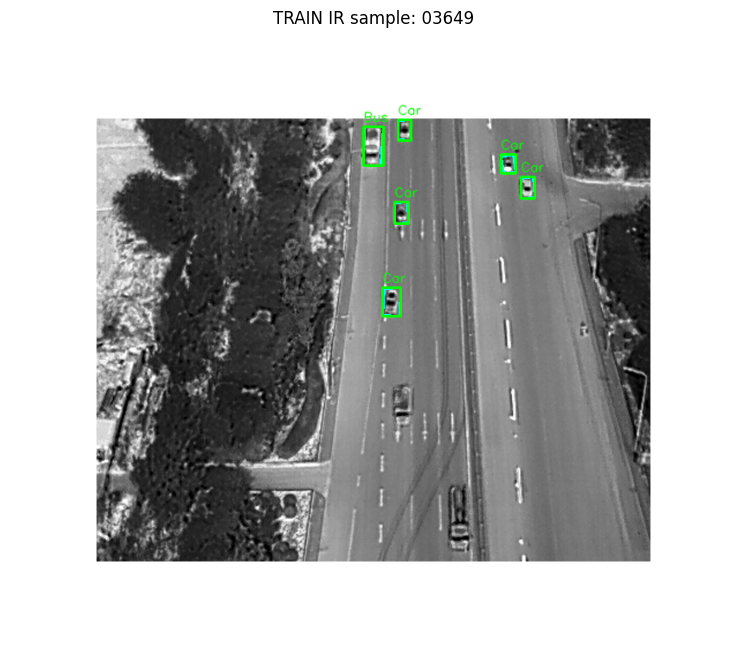

In [5]:
# ============================================================
# Cell 4: Inspect One DroneVehicle Infrared Annotation Pair
# + Visualize Boxes
# Robust XML parsing + class-remap sanity check + polygon->bbox conversion
# ============================================================

import xml.etree.ElementTree as ET

INSPECT_SPLIT = "train"

# Optional: set to a specific stem like "00001"
# If None, a reproducible random infrared sample is used.
INSPECT_STEM = None

assert INSPECT_SPLIT in DATASET_STRUCTURE, f"Unknown split: {INSPECT_SPLIT}"

ir_images_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["ir_images_dir"]
ir_labels_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["ir_labels_dir"]

paired_stems = DATASET_STRUCTURE[INSPECT_SPLIT]["paired_stems"]
assert len(paired_stems) > 0, f"No paired stems found for split: {INSPECT_SPLIT}"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def resolve_image_path(images_dir: Path, stem: str) -> Path:
    candidates = [
        images_dir / f"{stem}.jpg",
        images_dir / f"{stem}.JPG",
        images_dir / f"{stem}.jpeg",
        images_dir / f"{stem}.JPEG",
        images_dir / f"{stem}.png",
        images_dir / f"{stem}.PNG",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No image found for stem '{stem}' in {images_dir}")

def parse_dronevehicle_xml(xml_path: Path):
    """
    Parse one DroneVehicle XML file.

    Returns:
        {
            "width": int,
            "height": int,
            "depth": int or None,
            "filename": str or None,
            "objects": [
                {
                    "raw_name": str,
                    "normalized_name": str,
                    "phase3_id": int,
                    "phase3_name": str,
                    "polygon": [(x1,y1), (x2,y2), (x3,y3), (x4,y4)],
                    "bbox_xyxy": [x_min, y_min, x_max, y_max],
                    "bbox_xywh": [x, y, w, h],
                    "truncated": int or None,
                    "difficult": int or None,
                },
                ...
            ]
        }
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size_node = root.find("size")
    assert size_node is not None, f"Missing <size> in XML: {xml_path}"

    width = int(size_node.findtext("width"))
    height = int(size_node.findtext("height"))
    depth_text = size_node.findtext("depth")
    depth = int(depth_text) if depth_text is not None else None

    filename = root.findtext("filename")

    parsed_objects = []
    skip_reasons = defaultdict(int)

    for obj_idx, obj in enumerate(root.findall("object")):
        raw_name = obj.findtext("name")
        if raw_name is None:
            skip_reasons["missing_name"] += 1
            continue

        try:
            normalized_name = normalize_dronevehicle_class_name(raw_name)
            phase3_id = dronevehicle_name_to_phase3_id(raw_name)
            phase3_name = PHASE3_CLASSES[phase3_id]
        except Exception:
            skip_reasons["unknown_class_name"] += 1
            continue

        polygon = obj.find("polygon")
        if polygon is None:
            skip_reasons["missing_polygon"] += 1
            continue

        try:
            x1 = int(float(polygon.findtext("x1")))
            y1 = int(float(polygon.findtext("y1")))
            x2 = int(float(polygon.findtext("x2")))
            y2 = int(float(polygon.findtext("y2")))
            x3 = int(float(polygon.findtext("x3")))
            y3 = int(float(polygon.findtext("y3")))
            x4 = int(float(polygon.findtext("x4")))
            y4 = int(float(polygon.findtext("y4")))
        except Exception:
            skip_reasons["invalid_polygon_coordinates"] += 1
            continue

        pts = [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]

        # Convert oriented polygon -> enclosing axis-aligned rectangle
        x_min = max(0, min(xs))
        y_min = max(0, min(ys))
        x_max = min(width - 1, max(xs))
        y_max = min(height - 1, max(ys))

        if x_max <= x_min or y_max <= y_min:
            skip_reasons["invalid_bbox_after_polygon_conversion"] += 1
            continue

        bbox_w = x_max - x_min
        bbox_h = y_max - y_min

        if bbox_w <= 0 or bbox_h <= 0:
            skip_reasons["non_positive_bbox"] += 1
            continue

        truncated_text = obj.findtext("truncated")
        difficult_text = obj.findtext("difficult")

        parsed_objects.append({
            "raw_name": raw_name,
            "normalized_name": normalized_name,
            "phase3_id": phase3_id,
            "phase3_name": phase3_name,
            "polygon": pts,
            "bbox_xyxy": [x_min, y_min, x_max, y_max],
            "bbox_xywh": [x_min, y_min, bbox_w, bbox_h],
            "truncated": int(truncated_text) if truncated_text is not None else None,
            "difficult": int(difficult_text) if difficult_text is not None else None,
        })

    return {
        "width": width,
        "height": height,
        "depth": depth,
        "filename": filename,
        "objects": parsed_objects,
        "skip_reasons": dict(skip_reasons),
    }

def draw_objects_on_image(img_bgr, parsed_ann, draw_polygon=True, draw_bbox=True):
    img_vis = img_bgr.copy()

    for obj in parsed_ann["objects"]:
        cls_name = obj["phase3_name"]
        pts = obj["polygon"]
        x_min, y_min, x_max, y_max = obj["bbox_xyxy"]

        if draw_polygon:
            poly = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))
            cv2.polylines(img_vis, [poly], isClosed=True, color=(255, 255, 0), thickness=2)

        if draw_bbox:
            cv2.rectangle(
                img_vis,
                (x_min, y_min),
                (x_max, y_max),
                (0, 255, 0),
                2
            )

        cv2.putText(
            img_vis,
            cls_name,
            (x_min, max(15, y_min - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    return img_vis

# ------------------------------------------------------------
# Pick sample stem
# ------------------------------------------------------------
if INSPECT_STEM is not None:
    sample_stem = INSPECT_STEM
    assert sample_stem in paired_stems, f"Stem '{sample_stem}' not found in split '{INSPECT_SPLIT}'"
else:
    rng = random.Random(SEED)
    sample_stem = rng.choice(paired_stems)

ir_xml_path = ir_labels_dir / f"{sample_stem}.xml"
ir_img_path = resolve_image_path(ir_images_dir, sample_stem)

assert ir_xml_path.exists(), f"IR XML not found: {ir_xml_path}"

print(f"Inspecting split       : {INSPECT_SPLIT}")
print(f"Sample stem            : {sample_stem}")
print(f"IR image               : {ir_img_path.name}")
print(f"IR annotation          : {ir_xml_path.name}")

# ------------------------------------------------------------
# Parse annotation
# ------------------------------------------------------------
ir_ann = parse_dronevehicle_xml(ir_xml_path)

print("\n=== Parsed IR Annotation Metadata ===")
print(f"filename: {ir_ann['filename']}")
print(f"size    : {ir_ann['width']} x {ir_ann['height']} x {ir_ann['depth']}")
print(f"objects : {len(ir_ann['objects'])}")
print(f"skipped : {sum(ir_ann['skip_reasons'].values())}")

if ir_ann["skip_reasons"]:
    print("\nIR skip reasons:")
    for reason, count in sorted(ir_ann["skip_reasons"].items()):
        print(f"  {reason}: {count}")

# ------------------------------------------------------------
# Print object-by-object sanity info
# ------------------------------------------------------------
phase3_counts = defaultdict(int)

print("\n=== Object Inspection (IR XML) ===")
for idx, obj in enumerate(ir_ann["objects"]):
    phase3_counts[obj["phase3_name"]] += 1
    print(
        f"Obj {idx:02d}: "
        f"raw='{obj['raw_name']}', "
        f"normalized='{obj['normalized_name']}', "
        f"phase3={obj['phase3_id']} ({obj['phase3_name']}), "
        f"polygon={obj['polygon']}, "
        f"bbox_xywh={obj['bbox_xywh']}, "
        f"truncated={obj['truncated']}, "
        f"difficult={obj['difficult']}"
    )

print("\n=== Inspection Summary ===")
print(f"Drawn objects: {len(ir_ann['objects'])}")

print("\nPhase 3 class counts in this sample:")
for cls_name in PHASE3_CLASS_NAMES:
    print(f"  {cls_name:<8}: {phase3_counts.get(cls_name, 0)}")

# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------
ir_img = cv2.imread(str(ir_img_path), cv2.IMREAD_COLOR)
assert ir_img is not None, f"Failed to load IR image: {ir_img_path}"

ir_vis = draw_objects_on_image(ir_img, ir_ann, draw_polygon=True, draw_bbox=True)
ir_vis = cv2.cvtColor(ir_vis, cv2.COLOR_BGR2RGB)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))
plt.imshow(ir_vis)
plt.axis("off")
plt.title(f"{INSPECT_SPLIT.upper()} IR sample: {sample_stem}")
plt.show()

In [6]:
# ============================================================
# Cell 5: COCO Schema View + Infrared-Isolated Training Contract
# ============================================================

print("=== COCO Categories (Canonical) ===")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")
print("===================================\n")

# ---- Target input resolution for RF-DETR Nano ----
# Keep 512 for stronger small-object performance.
TARGET_IMAGE_SIZE = 512

print(f"Target model input resolution: {TARGET_IMAGE_SIZE} x {TARGET_IMAGE_SIZE}\n")

# ---- DroneVehicle infrared image geometry ----
# Assumed dataset geometry:
# - downloaded image size is 840 x 712
# - white border of 100 px exists on all four sides
# - we crop the border before COCO export / training
DRONEVEHICLE_ORIGINAL_IMAGE_SIZE = {
    "width": 840,
    "height": 712,
}

DRONEVEHICLE_BORDER_POLICY = {
    "remove_white_border": True,
    "border_pixels": {
        "left": 100,
        "right": 100,
        "top": 100,
        "bottom": 100,
    },
    "expected_cropped_size": {
        "width": 840 - 100 - 100,   # 640
        "height": 712 - 100 - 100,  # 512
    },
    "apply_during_coco_export": True,
    "apply_consistently_to_ir": True,
    "adjust_annotation_coordinates_after_crop": True,
}

print("=== DroneVehicle Border Policy ===")
for k, v in DRONEVEHICLE_BORDER_POLICY.items():
    print(f"{k}: {v}")
print("==================================\n")

# ---- Preprocessing policy (INFRARED-ISOLATED) ----
PREPROCESSING_POLICY = {
    "image": {
        "target_size": TARGET_IMAGE_SIZE,
        "resize_enabled": True,
        "resize_method": "resize_longest_side_then_pad",
        "preserve_aspect_ratio": True,
        "pad_value": 0,
        "input_expected_after_border_crop": {
            "width": DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["width"],
            "height": DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["height"],
        },
    },
    "annotations": {
        "source_format": "xml_polygon",
        "source_box_type": "oriented_box_polygon",
        "convert_to_axis_aligned_coco_bbox": True,
        "polygon_to_bbox_method": "minmax_enclosing_rectangle",
        "crop_boxes_with_image": True,
        "clip_boxes_to_image": True,
        "filter_non_positive_boxes": True,
        "min_box_area_px_after_resize": 4,
    },
    "normalization": {
        "enabled": True,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "training_infrared_isolated": {
        "continuation_training": False,
        "initialize_from_previous_checkpoint": False,
        "start_from_base_pretrained_rfdetr": True,
        "source_checkpoint_family": None,
        "small_object_focus": True,
        "aggressive_random_crop": False,
        "heavy_downscale_augmentation": False,
        "modality": "infrared_only",
        "notes": (
            "This notebook trains RF-DETR Nano only on DroneVehicle infrared images. "
            "It does not load rgb-image-training or rgb-video-training checkpoints. "
            "XML oriented polygons are converted into axis-aligned COCO boxes."
        ),
    }
}

# ---- Experiment metadata ----
EXPERIMENT_METADATA = {
    "experiment_name": "infrared-isolated-training",
    "based_on": "base-rfdetr-pretrained-weights",
    "dataset_name": "DroneVehicle",
    "dataset_modalities": ["infrared"],
    "primary_change_1": "train only on DroneVehicle infrared images",
    "primary_change_2": "do not initialize from rgb-image-training or rgb-video-training checkpoints",
    "primary_change_3": "convert XML oriented polygons into axis-aligned COCO boxes",
    "primary_change_4": "remove 100-pixel white border before export/training",
    "expected_effect": (
        "cleaner modality-specific learning on infrared aerial vehicle imagery "
        "without cross-modality interference from RGB data"
    ),
}

# ---- Compact metadata bundle for later cells ----
TRAINING_CONTRACT = {
    "num_classes": NUM_CLASSES,
    "class_names": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "original_image_size": DRONEVEHICLE_ORIGINAL_IMAGE_SIZE,
    "border_policy": DRONEVEHICLE_BORDER_POLICY,
    "preprocessing_policy": PREPROCESSING_POLICY,
    "experiment_metadata": EXPERIMENT_METADATA,
}

print("=== Preprocessing Policy ===")
for section, cfg in PREPROCESSING_POLICY.items():
    print(f"{section}: {cfg}")
print("============================\n")

print("=== Experiment Metadata ===")
for k, v in EXPERIMENT_METADATA.items():
    print(f"{k}: {v}")
print("===========================\n")

print("=== Training Contract Summary ===")
print(f"num_classes       : {TRAINING_CONTRACT['num_classes']}")
print(f"class_names       : {TRAINING_CONTRACT['class_names']}")
print(f"target_image_size : {TRAINING_CONTRACT['target_image_size']}")
print(f"dataset_name      : {TRAINING_CONTRACT['experiment_metadata']['dataset_name']}")
print(f"experiment_name   : {TRAINING_CONTRACT['experiment_metadata']['experiment_name']}")
print("=================================")

=== COCO Categories (Canonical) ===
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Other

Target model input resolution: 512 x 512

=== DroneVehicle Border Policy ===
remove_white_border: True
border_pixels: {'left': 100, 'right': 100, 'top': 100, 'bottom': 100}
expected_cropped_size: {'width': 640, 'height': 512}
apply_during_coco_export: True
apply_consistently_to_ir: True
adjust_annotation_coordinates_after_crop: True

=== Preprocessing Policy ===
image: {'target_size': 512, 'resize_enabled': True, 'resize_method': 'resize_longest_side_then_pad', 'preserve_aspect_ratio': True, 'pad_value': 0, 'input_expected_after_border_crop': {'width': 640, 'height': 512}}
annotations: {'source_format': 'xml_polygon', 'source_box_type': 'oriented_box_polygon', 'convert_to_axis_aligned_coco_bbox': True, 'polygon_to_bbox_method': 'minmax_enclosing_rectangle', 'crop_boxes_with_image': True, 'clip_boxes_to_image': True, 'filter_non_posit

In [7]:
# ============================================================
# Cell 6: Create or Reuse DroneVehicle Infrared -> COCO Exports
# INFRARED-ONLY version
# ============================================================

import xml.etree.ElementTree as ET

COCO_OUTPUT_DIR = PROJECT_ROOT / "coco_annotations_dronevehicle_infrared"
COCO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COCO_EXPORT_SUMMARY = {}

COCO_TRAIN_JSON = COCO_OUTPUT_DIR / "dronevehicle_infrared_train_coco.json"
COCO_VAL_JSON   = COCO_OUTPUT_DIR / "dronevehicle_infrared_val_coco.json"
COCO_TEST_JSON  = COCO_OUTPUT_DIR / "dronevehicle_infrared_test_coco.json"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def get_border_crop_params():
    border_cfg = DRONEVEHICLE_BORDER_POLICY["border_pixels"]
    left = int(border_cfg["left"])
    right = int(border_cfg["right"])
    top = int(border_cfg["top"])
    bottom = int(border_cfg["bottom"])
    return left, right, top, bottom

def compute_cropped_dimensions(width: int, height: int):
    if not DRONEVEHICLE_BORDER_POLICY["remove_white_border"]:
        return width, height

    left, right, top, bottom = get_border_crop_params()
    cropped_w = width - left - right
    cropped_h = height - top - bottom

    if cropped_w <= 0 or cropped_h <= 0:
        raise ValueError(
            f"Invalid cropped size after border removal: "
            f"orig=({width}, {height}), crop=({cropped_w}, {cropped_h})"
        )

    return cropped_w, cropped_h

def parse_dronevehicle_xml_for_coco(xml_path: Path):
    """
    Parse one DroneVehicle XML into raw object polygons + metadata.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size_node = root.find("size")
    assert size_node is not None, f"Missing <size> in XML: {xml_path}"

    width = int(size_node.findtext("width"))
    height = int(size_node.findtext("height"))
    depth_text = size_node.findtext("depth")
    depth = int(depth_text) if depth_text is not None else None
    filename = root.findtext("filename")

    objects = []
    skip_reasons = defaultdict(int)

    for obj in root.findall("object"):
        raw_name = obj.findtext("name")
        if raw_name is None:
            skip_reasons["missing_name"] += 1
            continue

        try:
            normalized_name = normalize_dronevehicle_class_name(raw_name)
            phase3_id = dronevehicle_name_to_phase3_id(raw_name)
            phase3_name = PHASE3_CLASSES[phase3_id]
        except Exception:
            skip_reasons["unknown_class_name"] += 1
            continue

        polygon = obj.find("polygon")
        if polygon is None:
            skip_reasons["missing_polygon"] += 1
            continue

        try:
            pts = [
                (float(polygon.findtext("x1")), float(polygon.findtext("y1"))),
                (float(polygon.findtext("x2")), float(polygon.findtext("y2"))),
                (float(polygon.findtext("x3")), float(polygon.findtext("y3"))),
                (float(polygon.findtext("x4")), float(polygon.findtext("y4"))),
            ]
        except Exception:
            skip_reasons["invalid_polygon_coordinates"] += 1
            continue

        truncated_text = obj.findtext("truncated")
        difficult_text = obj.findtext("difficult")

        objects.append({
            "raw_name": raw_name,
            "normalized_name": normalized_name,
            "phase3_id": phase3_id,
            "phase3_name": phase3_name,
            "polygon": pts,
            "truncated": int(truncated_text) if truncated_text is not None else 0,
            "difficult": int(difficult_text) if difficult_text is not None else 0,
        })

    return {
        "width": width,
        "height": height,
        "depth": depth,
        "filename": filename,
        "objects": objects,
        "skip_reasons": dict(skip_reasons),
    }

def convert_polygon_to_coco_bbox(
    polygon_pts,
    orig_width: int,
    orig_height: int,
    remove_border: bool = True,
):
    """
    Convert 4-point polygon -> cropped/clipped axis-aligned COCO bbox [x, y, w, h].
    """
    xs = [p[0] for p in polygon_pts]
    ys = [p[1] for p in polygon_pts]

    if remove_border:
        left, right, top, bottom = get_border_crop_params()
        cropped_width = orig_width - left - right
        cropped_height = orig_height - top - bottom

        xs = [x - left for x in xs]
        ys = [y - top for y in ys]

        img_w = cropped_width
        img_h = cropped_height
    else:
        img_w = orig_width
        img_h = orig_height

    x_min = min(xs)
    y_min = min(ys)
    x_max = max(xs)
    y_max = max(ys)

    x_min = max(0.0, min(x_min, img_w))
    y_min = max(0.0, min(y_min, img_h))
    x_max = max(0.0, min(x_max, img_w))
    y_max = max(0.0, min(y_max, img_h))

    bbox_w = x_max - x_min
    bbox_h = y_max - y_min

    if bbox_w <= 0 or bbox_h <= 0:
        return None

    return [x_min, y_min, bbox_w, bbox_h]

def resolve_image_path(images_dir: Path, stem: str) -> Path:
    candidates = [
        images_dir / f"{stem}.jpg",
        images_dir / f"{stem}.JPG",
        images_dir / f"{stem}.jpeg",
        images_dir / f"{stem}.JPEG",
        images_dir / f"{stem}.png",
        images_dir / f"{stem}.PNG",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No image found for stem '{stem}' in {images_dir}")

def load_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

def inspect_coco_export(json_path: Path, split_name: str):
    coco_json = load_json(json_path)

    categories = sorted(coco_json["categories"], key=lambda c: c["id"])
    cat_ids = [c["id"] for c in categories]
    cat_names = [c["name"] for c in categories]

    assert cat_ids == list(range(1, NUM_CLASSES + 1)), (
        f"Category ID mismatch in {json_path.name}: {cat_ids}"
    )
    assert cat_names == PHASE3_CLASS_NAMES, (
        f"Category name mismatch in {json_path.name}.\n"
        f"Expected: {PHASE3_CLASS_NAMES}\n"
        f"Got     : {cat_names}"
    )

    images_total = len(coco_json["images"])
    annotations_total = len(coco_json["annotations"])

    assert images_total > 0, f"{json_path.name} has zero images"
    assert annotations_total > 0, f"{json_path.name} has zero annotations"

    phase3_class_counts = defaultdict(int)

    for img in coco_json["images"]:
        assert img.get("modality") == "ir", f"Found non-IR modality in {json_path.name}: {img.get('modality')}"

    for ann in coco_json["annotations"]:
        cat_id = ann["category_id"]
        assert cat_id in PHASE3_CLASSES, f"Invalid category_id={cat_id} in {json_path.name}"

        x, y, w, h = ann["bbox"]
        assert w > 0 and h > 0, f"Non-positive bbox found in {json_path.name}: {ann['bbox']}"

        phase3_class_counts[PHASE3_CLASSES[cat_id]] += 1

    summary = {
        "split": split_name,
        "images_total": images_total,
        "annotations_total": annotations_total,
        "ir_images_total": images_total,
        "phase3_class_counts": dict(phase3_class_counts),
        "output_json_path": str(json_path),
    }
    return summary

def is_coco_export_ready(json_path: Path, split_name: str):
    if not json_path.exists():
        return False

    try:
        _ = inspect_coco_export(json_path, split_name)
        return True
    except Exception as e:
        print(f"[WARN] Existing COCO export invalid for split '{split_name}': {e}")
        return False

# ------------------------------------------------------------
# Main conversion
# ------------------------------------------------------------
def convert_dronevehicle_ir_split_to_coco(split_name, output_json_path):
    """
    Convert one DroneVehicle infrared split into COCO format.
    """
    assert split_name in DATASET_STRUCTURE, f"Unknown split: {split_name}"

    split_info = DATASET_STRUCTURE[split_name]
    ir_images_dir = split_info["ir_images_dir"]
    ir_labels_dir = split_info["ir_labels_dir"]
    paired_stems = split_info["paired_stems"]

    coco = {
        "info": {
            "description": (
                f"DroneVehicle infrared converted to COCO using canonical Phase 3 taxonomy "
                f"({split_name}); infrared-only export"
            ),
            "version": "1.0",
            "split": split_name,
            "dataset_name": "DroneVehicle",
            "modality": "infrared",
            "num_classes": NUM_CLASSES,
            "class_names": PHASE3_CLASS_NAMES,
            "border_removed": DRONEVEHICLE_BORDER_POLICY["remove_white_border"],
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": COCO_CATEGORIES,
    }

    stats = {
        "split": split_name,
        "paired_stems_total": len(paired_stems),
        "images_total": 0,
        "annotations_total": 0,
        "skip_reasons": defaultdict(int),
        "phase3_class_counts": defaultdict(int),
    }

    image_id = 1
    annotation_id = 1

    print(f"\n=== Converting split: {split_name} ===")
    print(f"Infrared stems found: {len(paired_stems)}")
    print(f"Output JSON         : {output_json_path}")
    print(f"Border removal      : {DRONEVEHICLE_BORDER_POLICY['remove_white_border']}")

    for stem in tqdm(paired_stems, desc=f"Converting {split_name}"):
        try:
            img_path = resolve_image_path(ir_images_dir, stem)
        except FileNotFoundError:
            stats["skip_reasons"]["missing_ir_image_file"] += 1
            continue

        xml_path = ir_labels_dir / f"{stem}.xml"
        if not xml_path.exists():
            stats["skip_reasons"]["missing_ir_xml_file"] += 1
            continue

        parsed = parse_dronevehicle_xml_for_coco(xml_path)
        for reason, count in parsed["skip_reasons"].items():
            stats["skip_reasons"][f"ir_{reason}"] += count

        orig_width = parsed["width"]
        orig_height = parsed["height"]
        final_width, final_height = compute_cropped_dimensions(orig_width, orig_height)

        coco_image_name = f"{split_name}_ir_{img_path.name}"

        coco["images"].append({
            "id": image_id,
            "file_name": coco_image_name,
            "width": final_width,
            "height": final_height,
            "modality": "ir",
            "original_file_name": img_path.name,
            "paired_stem": stem,
        })

        stats["images_total"] += 1
        image_annotation_count_before = stats["annotations_total"]

        for obj in parsed["objects"]:
            coco_bbox = convert_polygon_to_coco_bbox(
                polygon_pts=obj["polygon"],
                orig_width=orig_width,
                orig_height=orig_height,
                remove_border=DRONEVEHICLE_BORDER_POLICY["remove_white_border"],
            )

            if coco_bbox is None:
                stats["skip_reasons"]["ir_box_invalid_after_crop_clip"] += 1
                continue

            x, y, w, h = coco_bbox

            if PREPROCESSING_POLICY["annotations"]["filter_non_positive_boxes"]:
                if w <= 0 or h <= 0:
                    stats["skip_reasons"]["ir_non_positive_box"] += 1
                    continue

            coco["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": obj["phase3_id"],
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0,
            })

            annotation_id += 1
            stats["annotations_total"] += 1
            stats["phase3_class_counts"][obj["phase3_name"]] += 1

        image_id += 1

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2)

    COCO_EXPORT_SUMMARY[split_name] = {
        "split": stats["split"],
        "paired_stems_total": stats["paired_stems_total"],
        "images_total": stats["images_total"],
        "annotations_total": stats["annotations_total"],
        "ir_images_total": stats["images_total"],
        "skip_reasons": dict(stats["skip_reasons"]),
        "phase3_class_counts": dict(stats["phase3_class_counts"]),
        "output_json_path": str(output_json_path),
    }

    print(f"\nFinished {split_name}:")
    print(f"  Infrared stems : {stats['paired_stems_total']}")
    print(f"  Images         : {stats['images_total']}")
    print(f"  Annotations    : {stats['annotations_total']}")

    print("\nPer-class converted counts:")
    for cls_name in PHASE3_CLASS_NAMES:
        print(f"  {cls_name:<8}: {stats['phase3_class_counts'].get(cls_name, 0)}")

    if stats["skip_reasons"]:
        print("\nSkip reasons:")
        for reason, count in sorted(stats["skip_reasons"].items()):
            print(f"  {reason}: {count}")

    print(f"\nSaved COCO annotations to: {output_json_path}")
    print("==============================================================")

def ensure_coco_export(split_name: str, output_json_path: Path):
    if is_coco_export_ready(output_json_path, split_name):
        print(f"[REUSE] Existing COCO export is valid for split '{split_name}'")
        COCO_EXPORT_SUMMARY[split_name] = inspect_coco_export(output_json_path, split_name)
        return

    print(f"[BUILD] COCO export needs creation or refresh for split '{split_name}'")
    convert_dronevehicle_ir_split_to_coco(split_name, output_json_path)

    assert is_coco_export_ready(output_json_path, split_name), (
        f"COCO export failed validation after rebuild for split '{split_name}'"
    )

    COCO_EXPORT_SUMMARY[split_name] = inspect_coco_export(output_json_path, split_name)

# ------------------------------------------------------------
# Ensure train / val / test exports exist and are valid
# ------------------------------------------------------------
ensure_coco_export("train", COCO_TRAIN_JSON)
ensure_coco_export("val", COCO_VAL_JSON)
ensure_coco_export("test", COCO_TEST_JSON)

print("\n=== COCO Export Summary ===")
for split, summary in COCO_EXPORT_SUMMARY.items():
    print(f"\n[{split.upper()}]")
    print(f"  images_total      : {summary['images_total']}")
    print(f"  annotations_total : {summary['annotations_total']}")
    print(f"  ir_images_total   : {summary['ir_images_total']}")
    print(f"  output_json_path  : {summary['output_json_path']}")

[BUILD] COCO export needs creation or refresh for split 'train'

=== Converting split: train ===
Infrared stems found: 17990
Output JSON         : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_train_coco.json
Border removal      : True


Converting train: 100%|███████████████████████████████████████████████████████████████████████| 17990/17990 [00:57<00:00, 311.84it/s]



Finished train:
  Infrared stems : 17990
  Images         : 17990
  Annotations    : 283026

Per-class converted counts:
  Human   : 0
  Bicycle : 0
  Car     : 256946
  Truck   : 15186
  Bus     : 10894
  Other   : 0

Skip reasons:
  ir_missing_polygon: 22211
  ir_unknown_class_name: 11197

Saved COCO annotations to: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_train_coco.json
[BUILD] COCO export needs creation or refresh for split 'val'

=== Converting split: val ===
Infrared stems found: 1469
Output JSON         : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_val_coco.json
Border removal      : True


Converting val: 100%|███████████████████████████████████████████████████████████████████████████| 1469/1469 [00:04<00:00, 309.88it/s]



Finished val:
  Infrared stems : 1469
  Images         : 1469
  Annotations    : 22145

Per-class converted counts:
  Human   : 0
  Bicycle : 0
  Car     : 19950
  Truck   : 1448
  Bus     : 747
  Other   : 0

Skip reasons:
  ir_missing_polygon: 1427
  ir_unknown_class_name: 918

Saved COCO annotations to: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_val_coco.json
[BUILD] COCO export needs creation or refresh for split 'test'

=== Converting split: test ===
Infrared stems found: 8980
Output JSON         : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_test_coco.json
Border removal      : True


Converting test: 100%|██████████████████████████████████████████████████████████████████████████| 8980/8980 [00:29<00:00, 308.43it/s]



Finished test:
  Infrared stems : 8980
  Images         : 8980
  Annotations    : 145089

Per-class converted counts:
  Human   : 0
  Bicycle : 0
  Car     : 132317
  Truck   : 8468
  Bus     : 4304
  Other   : 0

Skip reasons:
  ir_box_invalid_after_crop_clip: 2
  ir_missing_polygon: 9477
  ir_unknown_class_name: 5064

Saved COCO annotations to: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_test_coco.json

=== COCO Export Summary ===

[TRAIN]
  images_total      : 17990
  annotations_total : 283026
  ir_images_total   : 17990
  output_json_path  : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_train_coco.json

[VAL]
  images_total      : 1469
  annotations_total : 22145
  ir_images_total   : 1469
  output_json_path  : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanpraka

Loading COCO annotations from:
/ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_dronevehicle_infrared/dronevehicle_infrared_train_coco.json

loading annotations into memory...
Done (t=0.75s)
creating index...
index created!
=== COCO Categories (Validated) ===
id=1 | name=Human
id=2 | name=Bicycle
id=3 | name=Car
id=4 | name=Truck
id=5 | name=Bus
id=6 | name=Other

=== Dataset Statistics ===
Images     : 17990
Annotations: 283026

=== Per-Class Annotation Counts ===
Human   : 0
Bicycle : 0
Car     : 256946
Truck   : 15186
Bus     : 10894
Other   : 0

=== Modality Counts ===
IR images     : 17990
Non-IR images : 0

=== Annotation Integrity Checks Passed ===
All category_ids are valid
All image references are valid
All boxes have positive width/height
All boxes lie within cropped image bounds



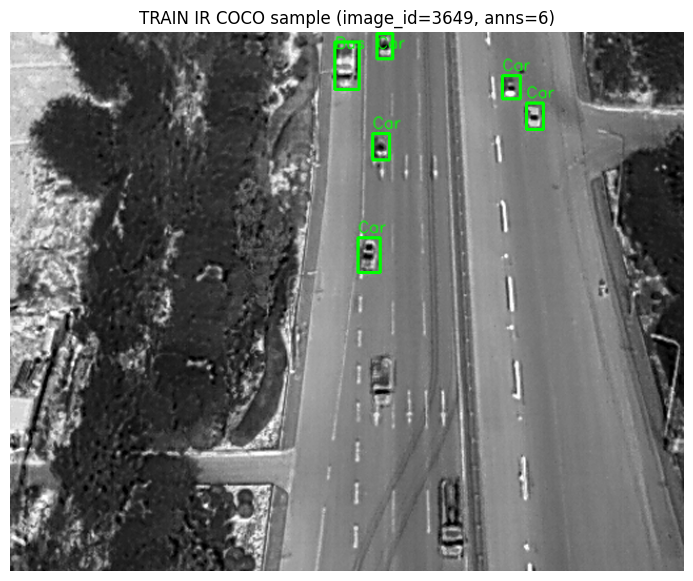

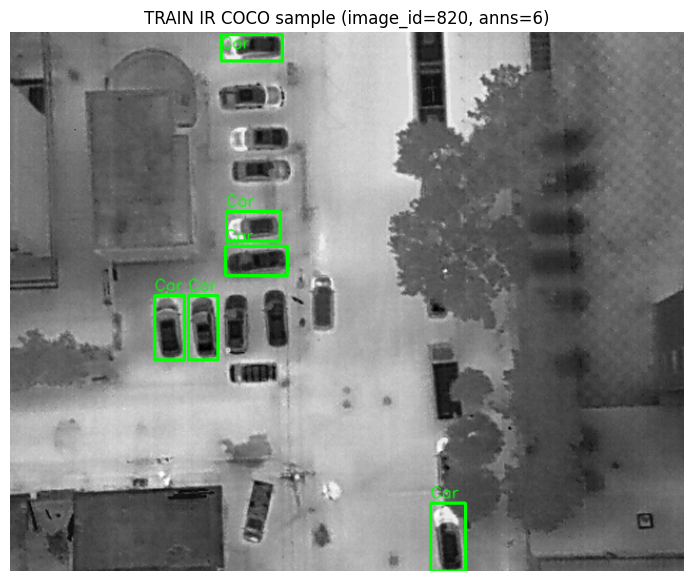

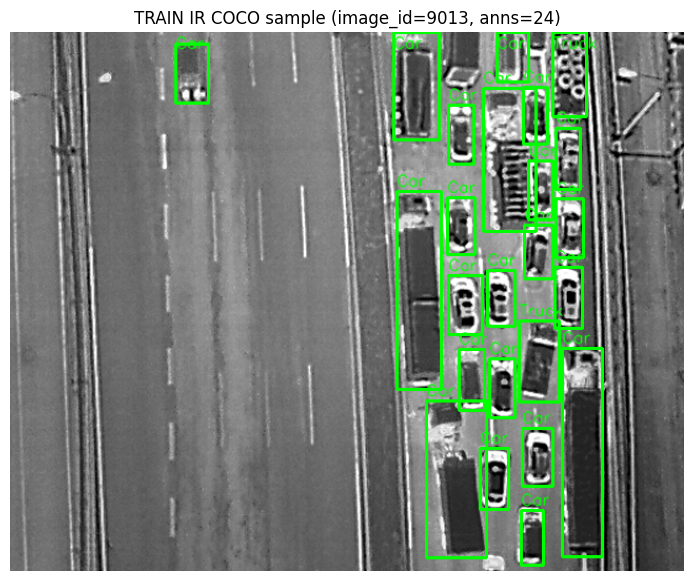

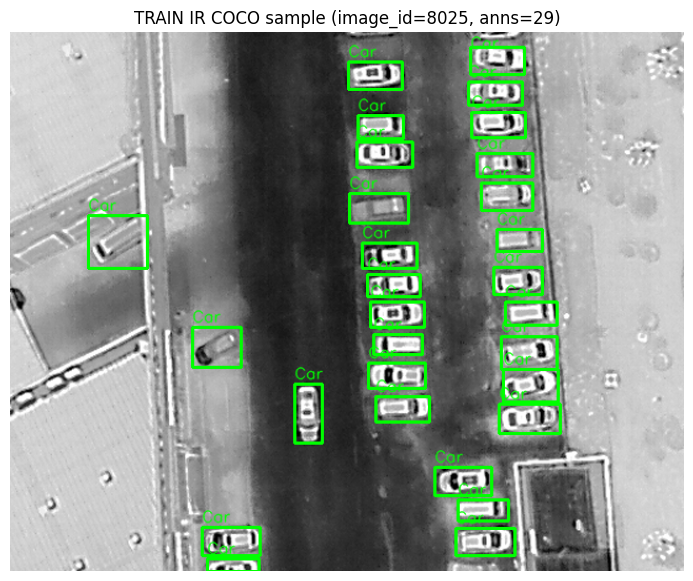

In [8]:
# ============================================================
# Cell 7: Validate Infrared COCO Output + Visual Sanity Check
# INFRARED-ONLY version
# ============================================================

VALIDATE_SPLIT = "train"

COCO_JSON_PATH = COCO_OUTPUT_DIR / f"dronevehicle_infrared_{VALIDATE_SPLIT}_coco.json"

assert COCO_JSON_PATH.exists(), f"COCO JSON not found: {COCO_JSON_PATH}"
assert VALIDATE_SPLIT in DATASET_STRUCTURE, f"Unknown split: {VALIDATE_SPLIT}"

print(f"Loading COCO annotations from:\n{COCO_JSON_PATH}\n")

coco = COCO(str(COCO_JSON_PATH))

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def parse_coco_export_file_name(file_name: str):
    """
    Expected format from Cell 6:
        <split>_ir_<original_image_name>
    Example:
        train_ir_00001.jpg
        val_ir_01234.JPG
    """
    prefix = f"{VALIDATE_SPLIT}_ir_"
    assert file_name.startswith(prefix), f"Unexpected file_name prefix: {file_name}"
    original_name = file_name[len(prefix):]
    return original_name

def crop_white_border(img_bgr):
    if not DRONEVEHICLE_BORDER_POLICY["remove_white_border"]:
        return img_bgr

    left = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["left"]
    right = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["right"]
    top = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["top"]
    bottom = DRONEVEHICLE_BORDER_POLICY["border_pixels"]["bottom"]

    h, w = img_bgr.shape[:2]
    cropped = img_bgr[top:h-bottom, left:w-right]

    expected_w = DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["width"]
    expected_h = DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["height"]

    assert cropped.shape[1] == expected_w, (
        f"Cropped width mismatch. Expected {expected_w}, got {cropped.shape[1]}"
    )
    assert cropped.shape[0] == expected_h, (
        f"Cropped height mismatch. Expected {expected_h}, got {cropped.shape[0]}"
    )

    return cropped

# ------------------------------------------------------------
# Verify categories against canonical metadata
# ------------------------------------------------------------
cats = sorted(coco.loadCats(coco.getCatIds()), key=lambda c: c["id"])
exported_cat_ids = [c["id"] for c in cats]
exported_cat_names = [c["name"] for c in cats]

assert exported_cat_ids == list(range(1, NUM_CLASSES + 1)), (
    f"Exported category ids mismatch.\n"
    f"Expected: {list(range(1, NUM_CLASSES + 1))}\n"
    f"Got     : {exported_cat_ids}"
)

assert exported_cat_names == PHASE3_CLASS_NAMES, (
    f"Exported category names mismatch.\n"
    f"Expected: {PHASE3_CLASS_NAMES}\n"
    f"Got     : {exported_cat_names}"
)

print("=== COCO Categories (Validated) ===")
for c in cats:
    print(f"id={c['id']} | name={c['name']}")
print("===================================\n")

# ------------------------------------------------------------
# Dataset statistics
# ------------------------------------------------------------
num_images = len(coco.getImgIds())
num_annotations = len(coco.getAnnIds())

print("=== Dataset Statistics ===")
print(f"Images     : {num_images}")
print(f"Annotations: {num_annotations}")
print("==========================\n")

# ------------------------------------------------------------
# Cross-check against conversion summary
# ------------------------------------------------------------
if VALIDATE_SPLIT in COCO_EXPORT_SUMMARY:
    expected_images = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["images_total"]
    expected_annotations = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["annotations_total"]

    assert num_images == expected_images, (
        f"Image count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_images}, got {num_images}"
    )
    assert num_annotations == expected_annotations, (
        f"Annotation count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_annotations}, got {num_annotations}"
    )

# ------------------------------------------------------------
# Per-class annotation counts
# ------------------------------------------------------------
print("=== Per-Class Annotation Counts ===")
for c in cats:
    cat_id = c["id"]
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    print(f"{c['name']:<8}: {len(ann_ids)}")
print("==================================\n")

# ------------------------------------------------------------
# Infrared-only modality check
# ------------------------------------------------------------
all_imgs = coco.loadImgs(coco.getImgIds())
ir_count = sum(1 for img in all_imgs if img.get("modality") == "ir")
non_ir_count = sum(1 for img in all_imgs if img.get("modality") != "ir")

print("=== Modality Counts ===")
print(f"IR images     : {ir_count}")
print(f"Non-IR images : {non_ir_count}")
print("=======================\n")

assert non_ir_count == 0, f"Found {non_ir_count} non-IR images in infrared-only COCO export"

if VALIDATE_SPLIT in COCO_EXPORT_SUMMARY:
    assert ir_count == COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["ir_images_total"], (
        f"IR image count mismatch. Expected {COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]['ir_images_total']}, got {ir_count}"
    )

# ------------------------------------------------------------
# Strong annotation sanity checks
# ------------------------------------------------------------
all_img_ids = set(coco.getImgIds())
all_anns = coco.loadAnns(coco.getAnnIds())

invalid_category_count = 0
invalid_image_ref_count = 0
invalid_box_count = 0
invalid_box_bounds_count = 0

img_id_to_info = {img["id"]: img for img in all_imgs}

for ann in all_anns:
    if ann["category_id"] not in PHASE3_CLASSES:
        invalid_category_count += 1

    if ann["image_id"] not in all_img_ids:
        invalid_image_ref_count += 1
        continue

    x, y, w, h = ann["bbox"]
    if w <= 0 or h <= 0:
        invalid_box_count += 1
        continue

    img_info = img_id_to_info[ann["image_id"]]
    img_w = img_info["width"]
    img_h = img_info["height"]

    if x < 0 or y < 0 or x + w > img_w + 1e-6 or y + h > img_h + 1e-6:
        invalid_box_bounds_count += 1

assert invalid_category_count == 0, f"Found {invalid_category_count} annotations with invalid category_id"
assert invalid_image_ref_count == 0, f"Found {invalid_image_ref_count} annotations with invalid image_id"
assert invalid_box_count == 0, f"Found {invalid_box_count} annotations with non-positive boxes"
assert invalid_box_bounds_count == 0, f"Found {invalid_box_bounds_count} annotations outside image bounds"

print("=== Annotation Integrity Checks Passed ===")
print("All category_ids are valid")
print("All image references are valid")
print("All boxes have positive width/height")
print("All boxes lie within cropped image bounds")
print("==========================================\n")

# ------------------------------------------------------------
# Visualize reproducible random samples
# IMPORTANT:
# - COCO boxes are in cropped-image coordinates
# - so we must load the original source image and crop the border first
# ------------------------------------------------------------
NUM_SAMPLES = 4
rng = random.Random(SEED)

sample_img_ids = rng.sample(coco.getImgIds(), min(NUM_SAMPLES, len(coco.getImgIds())))

split_info = DATASET_STRUCTURE[VALIDATE_SPLIT]
ir_images_dir = split_info["ir_images_dir"]

for img_id in sample_img_ids:
    img_info = coco.loadImgs(img_id)[0]
    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    modality = img_info.get("modality")
    assert modality == "ir", f"Expected IR modality, got {modality}"

    coco_file_name = img_info["file_name"]
    original_image_name = parse_coco_export_file_name(coco_file_name)

    source_img_path = ir_images_dir / original_image_name
    assert source_img_path.exists(), f"Source image not found: {source_img_path}"

    img = cv2.imread(str(source_img_path), cv2.IMREAD_COLOR)
    assert img is not None, f"Failed to load image: {source_img_path}"

    img = crop_white_border(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for ann in anns:
        x, y, w, h = ann["bbox"]
        x1, y1, x2, y2 = map(int, [x, y, x + w, y + h])

        cls_name = class_id_to_name(ann["category_id"])

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )
        cv2.putText(
            img,
            cls_name,
            (x1, max(15, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{VALIDATE_SPLIT.upper()} IR COCO sample "
        f"(image_id={img_id}, anns={len(anns)})"
    )
    plt.show()

In [9]:
# ============================================================
# Cell 8: Create or Reuse COCO-Compatible Dataset Shim for RF-DETR
# Infrared-only version
# Crop + rename DroneVehicle infrared images to match COCO export
# ============================================================

import shutil

print("\n=== Create / Reuse RF-DETR COCO dataset shim (infrared-only) ===\n")

# ---- COCO annotation source dir from Cell 6 ----
COCO_ANN_SRC = COCO_OUTPUT_DIR

# ---- Dedicated shim root for infrared-only notebook ----
SHIM_ROOT = PROJECT_ROOT / "infrared-data-shim"

# ---- RF-DETR expected COCO-style structure ----
COCO_TRAIN_IMG = SHIM_ROOT / "train2017"
COCO_VAL_IMG   = SHIM_ROOT / "val2017"
COCO_TEST_IMG  = SHIM_ROOT / "test2017"
COCO_ANN_DIR   = SHIM_ROOT / "annotations"

COCO_TRAIN_ANN = COCO_ANN_DIR / "instances_train2017.json"
COCO_VAL_ANN   = COCO_ANN_DIR / "instances_val2017.json"
COCO_TEST_ANN  = COCO_ANN_DIR / "instances_test2017.json"

# ---- Create directories ----
for d in [COCO_TRAIN_IMG, COCO_VAL_IMG, COCO_TEST_IMG, COCO_ANN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Source annotation JSONs ----
TRAIN_SRC_ANN = COCO_ANN_SRC / "dronevehicle_infrared_train_coco.json"
VAL_SRC_ANN   = COCO_ANN_SRC / "dronevehicle_infrared_val_coco.json"
TEST_SRC_ANN  = COCO_ANN_SRC / "dronevehicle_infrared_test_coco.json"

assert TRAIN_SRC_ANN.exists(), f"Missing train COCO json: {TRAIN_SRC_ANN}"
assert VAL_SRC_ANN.exists(), f"Missing val COCO json: {VAL_SRC_ANN}"
assert TEST_SRC_ANN.exists(), f"Missing test COCO json: {TEST_SRC_ANN}"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def crop_white_border(img_bgr):
    if not DRONEVEHICLE_BORDER_POLICY["remove_white_border"]:
        return img_bgr

    left = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["left"])
    right = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["right"])
    top = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["top"])
    bottom = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["bottom"])

    h, w = img_bgr.shape[:2]
    cropped = img_bgr[top:h-bottom, left:w-right]

    expected_w = int(DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["width"])
    expected_h = int(DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["height"])

    assert cropped.shape[1] == expected_w, (
        f"Cropped width mismatch. Expected {expected_w}, got {cropped.shape[1]}"
    )
    assert cropped.shape[0] == expected_h, (
        f"Cropped height mismatch. Expected {expected_h}, got {cropped.shape[0]}"
    )

    return cropped

def resolve_original_ir_image_path(split_name: str, original_image_name: str) -> Path:
    split_info = DATASET_STRUCTURE[split_name]
    base_dir = split_info["ir_images_dir"]

    candidate = base_dir / original_image_name
    if candidate.exists():
        return candidate

    stem = Path(original_image_name).stem
    ext_candidates = [".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"]

    for ext in ext_candidates:
        p = base_dir / f"{stem}{ext}"
        if p.exists():
            return p

    raise FileNotFoundError(
        f"Could not resolve infrared image for split={split_name}, "
        f"original_image_name={original_image_name}"
    )

def list_image_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    )

def load_coco_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

def validate_annotation_json(src_json: Path, dst_json: Path, split_name: str):
    assert dst_json.exists(), f"{split_name} shim annotation json missing: {dst_json}"

    src_coco = load_coco_json(src_json)
    dst_coco = load_coco_json(dst_json)

    src_categories = sorted(src_coco["categories"], key=lambda c: c["id"])
    dst_categories = sorted(dst_coco["categories"], key=lambda c: c["id"])

    src_cat_ids = [c["id"] for c in src_categories]
    dst_cat_ids = [c["id"] for c in dst_categories]

    src_cat_names = [c["name"] for c in src_categories]
    dst_cat_names = [c["name"] for c in dst_categories]

    assert dst_cat_ids == list(range(1, NUM_CLASSES + 1)), (
        f"{split_name} annotation ids mismatch: {dst_cat_ids}"
    )
    assert dst_cat_names == PHASE3_CLASS_NAMES, (
        f"{split_name} annotation names mismatch.\n"
        f"Expected: {PHASE3_CLASS_NAMES}\n"
        f"Got     : {dst_cat_names}"
    )

    assert src_cat_ids == dst_cat_ids, (
        f"{split_name} source/destination category id mismatch.\n"
        f"Source: {src_cat_ids}\n"
        f"Dest  : {dst_cat_ids}"
    )
    assert src_cat_names == dst_cat_names, (
        f"{split_name} source/destination category name mismatch.\n"
        f"Source: {src_cat_names}\n"
        f"Dest  : {dst_cat_names}"
    )

    assert len(src_coco["images"]) == len(dst_coco["images"]), (
        f"{split_name} source/destination image count mismatch in JSON.\n"
        f"Source: {len(src_coco['images'])}\n"
        f"Dest  : {len(dst_coco['images'])}"
    )
    assert len(src_coco["annotations"]) == len(dst_coco["annotations"]), (
        f"{split_name} source/destination annotation count mismatch in JSON.\n"
        f"Source: {len(src_coco['annotations'])}\n"
        f"Dest  : {len(dst_coco['annotations'])}"
    )

    for img in dst_coco["images"]:
        assert img.get("modality") == "ir", (
            f"{split_name} shim contains non-IR image entry: {img}"
        )

def is_split_shim_ready(src_ann_json: Path, dst_img_dir: Path, dst_ann_json: Path, split_name: str):
    """
    Returns True if the split shim already looks valid and can be reused.
    """
    if not src_ann_json.exists():
        return False
    if not dst_img_dir.exists():
        return False
    if not dst_ann_json.exists():
        return False

    src_coco = load_coco_json(src_ann_json)
    expected_count = len(src_coco["images"])
    existing_images = list_image_files(dst_img_dir)

    if expected_count == 0:
        return False
    if len(existing_images) != expected_count:
        return False

    try:
        validate_annotation_json(src_ann_json, dst_ann_json, split_name)
    except Exception as e:
        print(f"[WARN] Existing {split_name} shim annotation validation failed: {e}")
        return False

    return True

def clear_split_dir(dst_img_dir: Path):
    existing_images = list_image_files(dst_img_dir)
    for p in existing_images:
        p.unlink()

def prepare_split_images_from_coco(src_ann_json: Path, dst_img_dir: Path, split_name: str):
    """
    Read IR-only COCO JSON from Cell 6 and physically materialize cropped images into the
    RF-DETR COCO-style image directory using the exact COCO file_name.
    """
    coco_json = load_coco_json(src_ann_json)
    images = coco_json["images"]
    expected_count = len(images)
    existing_images = list_image_files(dst_img_dir)

    if len(existing_images) == expected_count and expected_count > 0:
        print(f"[SKIP] {split_name} images already prepared ({expected_count} files)")
        return

    if len(existing_images) > 0:
        print(f"[WARN] {split_name} destination has stale/partial contents; refreshing it")
        clear_split_dir(dst_img_dir)

    print(f"[PREP] {split_name}: materializing {expected_count} cropped infrared COCO images")

    for img_info in tqdm(images, desc=f"Preparing {split_name} images"):
        coco_file_name = img_info["file_name"]
        modality = img_info.get("modality")
        original_image_name = img_info.get("original_file_name")

        assert modality == "ir", (
            f"Missing/invalid modality for IR-only COCO image entry: {img_info}"
        )
        assert original_image_name is not None, (
            f"Missing original_file_name in COCO image entry: {img_info}"
        )

        src_img_path = resolve_original_ir_image_path(
            split_name=split_name,
            original_image_name=original_image_name,
        )
        dst_img_path = dst_img_dir / coco_file_name

        img = cv2.imread(str(src_img_path), cv2.IMREAD_COLOR)
        assert img is not None, f"Failed to load image: {src_img_path}"

        img = crop_white_border(img)

        expected_w = int(img_info["width"])
        expected_h = int(img_info["height"])

        assert img.shape[1] == expected_w, (
            f"{split_name} width mismatch for {coco_file_name}: "
            f"expected {expected_w}, got {img.shape[1]}"
        )
        assert img.shape[0] == expected_h, (
            f"{split_name} height mismatch for {coco_file_name}: "
            f"expected {expected_h}, got {img.shape[0]}"
        )

        ok = cv2.imwrite(str(dst_img_path), img)
        assert ok, f"Failed to save cropped image: {dst_img_path}"

    final_count = len(list_image_files(dst_img_dir))
    assert final_count == expected_count, (
        f"{split_name} image preparation failed: expected {expected_count}, got {final_count}"
    )

def copy_annotation_if_needed(src: Path, dst: Path, split_name: str):
    """
    Copy annotation JSON only if missing or if source/destination differ in key counts.
    """
    should_copy = True

    if dst.exists():
        try:
            src_coco = load_coco_json(src)
            dst_coco = load_coco_json(dst)

            same_images = len(src_coco["images"]) == len(dst_coco["images"])
            same_anns = len(src_coco["annotations"]) == len(dst_coco["annotations"])
            same_cats = src_coco["categories"] == dst_coco["categories"]

            if same_images and same_anns and same_cats:
                should_copy = False
        except Exception:
            should_copy = True

    if should_copy:
        shutil.copy2(src, dst)
        print(f"[COPY] {split_name} annotation -> {dst.name}")
    else:
        print(f"[SKIP] {split_name} annotation already valid -> {dst.name}")

    validate_annotation_json(src, dst, split_name)

def ensure_split_shim(src_ann_json: Path, dst_img_dir: Path, dst_ann_json: Path, split_name: str):
    """
    Reuse a valid split shim if present; otherwise rebuild it.
    """
    if is_split_shim_ready(src_ann_json, dst_img_dir, dst_ann_json, split_name):
        print(f"[REUSE] {split_name} shim already valid")
        return

    print(f"[BUILD] {split_name} shim needs creation or refresh")
    prepare_split_images_from_coco(src_ann_json, dst_img_dir, split_name)
    copy_annotation_if_needed(src_ann_json, dst_ann_json, split_name)

    assert is_split_shim_ready(src_ann_json, dst_img_dir, dst_ann_json, split_name), (
        f"{split_name} shim failed final validation after rebuild"
    )

# ------------------------------------------------------------
# Ensure train / val / test shim exists and is valid
# ------------------------------------------------------------
ensure_split_shim(TRAIN_SRC_ANN, COCO_TRAIN_IMG, COCO_TRAIN_ANN, "train")
ensure_split_shim(VAL_SRC_ANN, COCO_VAL_IMG, COCO_VAL_ANN, "val")
ensure_split_shim(TEST_SRC_ANN, COCO_TEST_IMG, COCO_TEST_ANN, "test")

# ------------------------------------------------------------
# Final validation summary
# ------------------------------------------------------------
train_dst_count = len(list_image_files(COCO_TRAIN_IMG))
val_dst_count = len(list_image_files(COCO_VAL_IMG))
test_dst_count = len(list_image_files(COCO_TEST_IMG))

print("\n=== COCO shim ready ===")
print(f"Shim root     : {SHIM_ROOT}")
print(f"Train images  : {COCO_TRAIN_IMG} ({train_dst_count} files)")
print(f"Val images    : {COCO_VAL_IMG} ({val_dst_count} files)")
print(f"Test images   : {COCO_TEST_IMG} ({test_dst_count} files)")
print(f"Annotations   : {COCO_ANN_DIR}")
print(f"Train ann     : {COCO_TRAIN_ANN.name}")
print(f"Val ann       : {COCO_VAL_ANN.name}")
print(f"Test ann      : {COCO_TEST_ANN.name}")
print("Canonical categories verified in shim annotation JSONs.")
print("Shim contains only infrared COCO images.")


=== Create / Reuse RF-DETR COCO dataset shim (infrared-only) ===

[BUILD] train shim needs creation or refresh
[PREP] train: materializing 17990 cropped infrared COCO images


Preparing train images: 100%|██████████████████████████████████████████████████████████████████| 17990/17990 [17:44<00:00, 16.90it/s]


[COPY] train annotation -> instances_train2017.json
[BUILD] val shim needs creation or refresh
[PREP] val: materializing 1469 cropped infrared COCO images


Preparing val images: 100%|██████████████████████████████████████████████████████████████████████| 1469/1469 [01:18<00:00, 18.61it/s]


[COPY] val annotation -> instances_val2017.json
[BUILD] test shim needs creation or refresh
[PREP] test: materializing 8980 cropped infrared COCO images


Preparing test images: 100%|█████████████████████████████████████████████████████████████████████| 8980/8980 [07:51<00:00, 19.06it/s]


[COPY] test annotation -> instances_test2017.json

=== COCO shim ready ===
Shim root     : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim
Train images  : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/train2017 (17990 files)
Val images    : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/val2017 (1469 files)
Test images   : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/test2017 (8980 files)
Annotations   : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/annotations
Train ann     : instances_train2017.json
Val ann       : instances_val2017.json
Test ann      : instances_test2017.json
Canonical categories verified in shim annotation JSONs.
Shim contains only infrared CO

In [10]:
# ============================================================
# Cell 9: Forward-Only RF-DETR Sanity Check
# NO training, NO backward pass
#
# Purpose:
# - Validate dataset + model compatibility
# - Catch class/count/path mismatches before training
# - Debug tensor / shape issues early
# ============================================================

import torch
from types import SimpleNamespace
from rfdetr import RFDETRNano
from rfdetr.datasets.coco import build as build_coco

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nRunning forward-only sanity check on device: {device}\n")

# ---- Verify shim paths exist ----
assert SHIM_ROOT.exists(), f"Missing shim root: {SHIM_ROOT}"
assert COCO_TRAIN_IMG.exists(), f"Missing COCO train image dir: {COCO_TRAIN_IMG}"
assert COCO_VAL_IMG.exists(), f"Missing COCO val image dir: {COCO_VAL_IMG}"
assert COCO_TRAIN_ANN.exists(), f"Missing COCO train annotation json: {COCO_TRAIN_ANN}"
assert COCO_VAL_ANN.exists(), f"Missing COCO val annotation json: {COCO_VAL_ANN}"

print("Using COCO shim root:", SHIM_ROOT)
print("Train images     :", COCO_TRAIN_IMG)
print("Val images       :", COCO_VAL_IMG)
print("Train ann        :", COCO_TRAIN_ANN)
print("Val ann          :", COCO_VAL_ANN)

# ---- Extra sanity: infrared-only COCO JSON ----
with open(COCO_TRAIN_ANN, "r", encoding="utf-8") as f:
    train_coco_json = json.load(f)

modalities_in_train_json = sorted(set(img.get("modality", "missing") for img in train_coco_json["images"]))
print("Modalities found in train annotation JSON:", modalities_in_train_json)
assert modalities_in_train_json == ["ir"], (
    f"Expected infrared-only COCO JSON, got modalities: {modalities_in_train_json}"
)

# ---- Initialize RF-DETR Nano with canonical class count ----
# No previous checkpoint loading here; this is just dataset/model compatibility.
model = RFDETRNano(num_classes=NUM_CLASSES)

# Access underlying torch model
torch_model = model.model.model
torch_model.to(device)
torch_model.eval()

# ---- Minimal args object required by RF-DETR COCO dataset builder ----
args = SimpleNamespace(
    dataset_file="coco",
    coco_path=str(SHIM_ROOT),
    square_resize_div_64=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,
    patch_size=16,
    num_windows=2,
)

# ---- Build training dataset from the infrared-only shim ----
dataset = build_coco(
    image_set="train",
    args=args,
    resolution=TARGET_IMAGE_SIZE,
)

print(f"\nDataset length: {len(dataset)}")
assert len(dataset) > 0, "Dataset is empty"

# Optional cross-check against export summary / shim size
if "train" in COCO_EXPORT_SUMMARY:
    expected_len = COCO_EXPORT_SUMMARY["train"]["images_total"]
    print(f"Expected train images from COCO export: {expected_len}")
    assert len(dataset) == expected_len, (
        f"Dataset length mismatch: expected {expected_len}, got {len(dataset)}"
    )

# ---- Try a few samples to avoid bad luck with dataset[0] ----
sample_indices = [0, min(1, len(dataset) - 1), min(5, len(dataset) - 1)]
sample_indices = sorted(set(sample_indices))

selected_sample = None
selected_targets = None
selected_idx = None

for idx in sample_indices:
    samples_i, targets_i = dataset[idx]

    if "boxes" in targets_i and "labels" in targets_i and len(targets_i["boxes"]) > 0:
        selected_sample = samples_i
        selected_targets = targets_i
        selected_idx = idx
        break

assert selected_sample is not None, "Could not find a non-empty sample in inspected dataset indices"

samples = selected_sample
targets = selected_targets

print(f"\nUsing dataset sample index: {selected_idx}")

print("\n=== Sample Inspection ===")
print(f"Sample tensor shape: {tuple(samples.shape)}")
print(f"Target keys        : {list(targets.keys())}")

assert "boxes" in targets, "Missing 'boxes' in targets"
assert "labels" in targets, "Missing 'labels' in targets"

num_target_boxes = len(targets["boxes"])
unique_labels = sorted(set(targets["labels"].cpu().numpy().tolist()))

print(f"Number of boxes    : {num_target_boxes}")
print(f"Unique label ids   : {unique_labels}")

assert num_target_boxes > 0, "Sample has zero target boxes"

# ---- Validate target labels ----
for label_id in unique_labels:
    assert 1 <= int(label_id) <= NUM_CLASSES, (
        f"Found out-of-range label_id={label_id}; expected within 1..{NUM_CLASSES}"
    )

# ---- Validate target boxes ----
boxes = targets["boxes"]
assert boxes.ndim == 2 and boxes.shape[1] == 4, (
    f"Expected target boxes shape [N, 4], got {tuple(boxes.shape)}"
)

box_min = boxes.min().item()
box_max = boxes.max().item()
print(f"Box value range    : min={box_min:.4f}, max={box_max:.4f}")

# Batchify
samples = samples.unsqueeze(0).to(device)
targets = [{k: v.to(device) for k, v in targets.items()}]

# ---- Forward pass ONLY ----
with torch.no_grad():
    outputs = torch_model(samples, targets)

print("\nForward pass successful")
print("Output keys:", list(outputs.keys()))

assert "pred_logits" in outputs, "Missing 'pred_logits' in model outputs"
assert "pred_boxes" in outputs, "Missing 'pred_boxes' in model outputs"

pred_logits = outputs["pred_logits"]
pred_boxes = outputs["pred_boxes"]

print("\n=== Output Shape Inspection ===")
print(f"pred_logits shape: {tuple(pred_logits.shape)}")
print(f"pred_boxes shape : {tuple(pred_boxes.shape)}")

assert pred_logits.ndim == 3, f"Expected pred_logits ndim=3, got {pred_logits.ndim}"
assert pred_boxes.ndim == 3, f"Expected pred_boxes ndim=3, got {pred_boxes.ndim}"
assert pred_boxes.shape[-1] == 4, (
    f"Expected pred_boxes last dim = 4, got {pred_boxes.shape[-1]}"
)

print("\n=== Class Mapping Check ===")
print(f"Canonical num_classes : {NUM_CLASSES}")
print(f"Canonical class names : {PHASE3_CLASS_NAMES}")

print("Forward-only sanity check passed.")


Running forward-only sanity check on device: cuda

Using COCO shim root: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim
Train images     : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/train2017
Val images       : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/val2017
Train ann        : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/annotations/instances_train2017.json
Val ann          : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim/annotations/instances_val2017.json
Modalities found in train annotation JSON: ['ir']
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuni

In [11]:
# ============================================================
# Cell 10: Infrared-Isolated Training Config + Canonical Metadata Export
# ============================================================

from datetime import datetime

assert torch.cuda.is_available(), "CUDA GPU is required."
print("GPU:", torch.cuda.get_device_name(0))

# ---- Required COCO shim paths ----
required = [
    SHIM_ROOT,
    COCO_TRAIN_IMG,
    COCO_VAL_IMG,
    COCO_TRAIN_ANN,
    COCO_VAL_ANN,
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing COCO-layout files/dirs:\n- "
        + "\n- ".join(missing)
        + "\n\nExpected:\n"
        "infrared-data-shim/train2017/*.jpg\n"
        "infrared-data-shim/val2017/*.jpg\n"
        "infrared-data-shim/annotations/instances_train2017.json\n"
        "infrared-data-shim/annotations/instances_val2017.json\n"
    )

# ---- Output dirs ----
OUT_ROOT = PROJECT_ROOT / "checkpoints"
LOG_DIR = PROJECT_ROOT / "logs"
META_DIR = PROJECT_ROOT / "run_metadata"

OUT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

# ---- Experiment identity ----
EXPERIMENT_NAME = "infrared-isolated-training"

# ---- Infrared-isolated training config ----
# We keep the safer 512-resolution setup:
# - batch_size=1 lowers per-step VRAM
# - grad_accum_steps=16 preserves effective batch size
#
# IMPORTANT:
# - dataset_dir / coco_path point to SHIM_ROOT
# - this run starts from base pretrained RF-DETR weights
# - no previous RGB checkpoint is loaded
TRAIN_CONFIG = {
    "dataset_file": "coco",
    "dataset_dir": str(SHIM_ROOT),
    "coco_path": str(SHIM_ROOT),
    "device": "cuda",

    "num_classes": NUM_CLASSES,
    "input_size": TARGET_IMAGE_SIZE,
    "resolution": TARGET_IMAGE_SIZE,

    "batch_size": 1,
    "grad_accum_steps": 16,  # effective batch = 16

    "epochs": 40,
    "lr": 1e-4,

    "amp": True,
    "use_ema": True,
    "do_benchmark": False,
    "fp16_eval": False,

    "early_stopping": True,
    "early_stopping_patience": 5,

    # Safe default
    "num_workers": 0,

    "checkpoint_interval": 1,
    "tensorboard": True,
}

print("\n=== Training Config ===")
for k, v in TRAIN_CONFIG.items():
    print(f"{k}: {v}")

# ---- Dataset summary from export/shim ----
train_images_total = COCO_EXPORT_SUMMARY.get("train", {}).get("images_total")
val_images_total = COCO_EXPORT_SUMMARY.get("val", {}).get("images_total")
train_annotations_total = COCO_EXPORT_SUMMARY.get("train", {}).get("annotations_total")
val_annotations_total = COCO_EXPORT_SUMMARY.get("val", {}).get("annotations_total")

print("\n=== Dataset Summary ===")
print(f"Train images      : {train_images_total}")
print(f"Train annotations : {train_annotations_total}")
print(f"Val images        : {val_images_total}")
print(f"Val annotations   : {val_annotations_total}")
print(f"Shim root         : {SHIM_ROOT}")

# ---- Save canonical metadata for future audit/debug ----
RUN_CANONICAL_METADATA = {
    "created_at": datetime.now().isoformat(),
    "experiment_name": EXPERIMENT_NAME,
    "based_on": "base-rfdetr-pretrained-weights",
    "dataset_name": "DroneVehicle",
    "dataset_modalities": ["infrared"],
    "continuation_checkpoint": None,
    "shim_root": str(SHIM_ROOT),

    "num_classes": NUM_CLASSES,
    "class_id_to_name": PHASE3_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,

    "target_image_size": TARGET_IMAGE_SIZE,
    "original_image_size": DRONEVEHICLE_ORIGINAL_IMAGE_SIZE,
    "border_policy": DRONEVEHICLE_BORDER_POLICY,
    "preprocessing_policy": PREPROCESSING_POLICY,
    "train_config": TRAIN_CONFIG,

    "dataset_summary": {
        "train_images_total": train_images_total,
        "train_annotations_total": train_annotations_total,
        "val_images_total": val_images_total,
        "val_annotations_total": val_annotations_total,
    },

    "notes": {
        "primary_change_1": "train only on DroneVehicle infrared images",
        "primary_change_2": "do not initialize from rgb-image-training or rgb-video-training checkpoints",
        "primary_change_3": "remove 100-pixel white border before export/training",
        "primary_change_4": "convert XML oriented polygons into axis-aligned COCO boxes",
        "primary_change_5": "use an infrared-only COCO shim for RF-DETR",
        "motivation": "learn a clean modality-specific detector on infrared aerial imagery while preserving the Phase 3 canonical taxonomy",
    },
}

CANONICAL_METADATA_PATH = META_DIR / f"{EXPERIMENT_NAME}_canonical_training_metadata.json"

with open(CANONICAL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_CANONICAL_METADATA, f, indent=2)

print(f"\nSaved canonical metadata to:\n{CANONICAL_METADATA_PATH}")

GPU: NVIDIA GeForce RTX 3090

=== Training Config ===
dataset_file: coco
dataset_dir: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim
coco_path: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim
device: cuda
num_classes: 6
input_size: 512
resolution: 512
batch_size: 1
grad_accum_steps: 16
epochs: 40
lr: 0.0001
amp: True
use_ema: True
do_benchmark: False
fp16_eval: False
early_stopping: True
early_stopping_patience: 5
num_workers: 0
checkpoint_interval: 1
tensorboard: True

=== Dataset Summary ===
Train images      : 17990
Train annotations : 283026
Val images        : 1469
Val annotations   : 22145
Shim root         : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim

Saved canonical metadata to:
/ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/

In [12]:
# ============================================================
# Cell 11: Full RF-DETR Infrared-Isolated Training Launch
# Minimal live status output
# ============================================================

import sys
import os
import time
import subprocess
import re
import json
from IPython.display import display, update_display, HTML

assert torch.cuda.is_available(), "CUDA GPU is required."

print("GPU:", torch.cuda.get_device_name(0))

run_name = time.strftime("infrared_isolated_training_%Y%m%d_%H%M%S")
output_dir = OUT_ROOT / run_name
output_dir.mkdir(parents=True, exist_ok=True)

log_path = LOG_DIR / f"{run_name}.log"
run_metadata_path = META_DIR / f"{run_name}_metadata.json"

FULL_TRAIN_CONFIG = dict(TRAIN_CONFIG)
FULL_TRAIN_CONFIG["output_dir"] = str(output_dir)

# ---- Save run metadata for this specific run ----
run_metadata = {
    "run_name": run_name,
    "experiment_name": "infrared-isolated-training",
    "based_on": "base-rfdetr-pretrained-weights",
    "dataset_name": "DroneVehicle",
    "dataset_modalities": ["infrared"],
    "log_path": str(log_path),
    "output_dir": str(output_dir),
    "seed": SEED,
    "source_checkpoint": None,
    "shim_root": str(SHIM_ROOT),
    "num_classes": NUM_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "class_id_to_name": PHASE3_CLASSES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "train_config": FULL_TRAIN_CONFIG,
    "dataset_summary": {
        "train_images_total": COCO_EXPORT_SUMMARY.get("train", {}).get("images_total"),
        "train_annotations_total": COCO_EXPORT_SUMMARY.get("train", {}).get("annotations_total"),
        "val_images_total": COCO_EXPORT_SUMMARY.get("val", {}).get("images_total"),
        "val_annotations_total": COCO_EXPORT_SUMMARY.get("val", {}).get("annotations_total"),
    },
    "notes": {
        "primary_change_1": "train only on DroneVehicle infrared images",
        "primary_change_2": "do not initialize from rgb-image-training or rgb-video-training checkpoints",
        "primary_change_3": "remove 100-pixel white border before export/training",
        "primary_change_4": "convert XML oriented polygons into axis-aligned COCO boxes",
        "primary_change_5": "use an infrared-only COCO shim for RF-DETR",
    },
}

with open(run_metadata_path, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print("Logs ->", log_path)
print("Checkpoints ->", output_dir)
print("Metadata ->", run_metadata_path)
print("Shim root ->", SHIM_ROOT)

# ---- Write a runner script so stdout/stderr can be fully captured ----
runner_path = output_dir / "_runner.py"
runner_path.write_text(
    "import torch\n"
    "from rfdetr import RFDETRNano\n"
    f"NUM_CLASSES = {NUM_CLASSES}\n"
    f"PHASE3_CLASS_NAMES = {repr(PHASE3_CLASS_NAMES)}\n"
    f"PHASE3_CLASSES = {repr(PHASE3_CLASSES)}\n"
    f"TARGET_IMAGE_SIZE = {TARGET_IMAGE_SIZE}\n"
    f"SEED = {SEED}\n"
    f"train_config = {repr(FULL_TRAIN_CONFIG)}\n"
    "print('=== Runner Startup ===', flush=True)\n"
    "print('Experiment : infrared-isolated-training', flush=True)\n"
    "print('Based on : base-rfdetr-pretrained-weights', flush=True)\n"
    "print('CUDA available :', torch.cuda.is_available(), flush=True)\n"
    "if torch.cuda.is_available():\n"
    "    print('GPU :', torch.cuda.get_device_name(0), flush=True)\n"
    "print('NUM_CLASSES :', NUM_CLASSES, flush=True)\n"
    "print('TARGET_IMAGE_SIZE:', TARGET_IMAGE_SIZE, flush=True)\n"
    "print('SEED :', SEED, flush=True)\n"
    "print('PHASE3_CLASS_NAMES:', PHASE3_CLASS_NAMES, flush=True)\n"
    "print('TRAIN_CONFIG :', train_config, flush=True)\n"
    "print('======================', flush=True)\n"
    "model = RFDETRNano(num_classes=NUM_CLASSES)\n"
    "model.train(**train_config)\n"
)

# ---- Launch training ----
env_vars = dict(os.environ)
env_vars["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

with open(log_path, "w", encoding="utf-8", buffering=1) as logf:
    proc = subprocess.Popen(
        [sys.executable, "-u", str(runner_path)],
        stdout=logf,
        stderr=subprocess.STDOUT,
        cwd=str(output_dir),
        env=env_vars,
        text=True,
    )

# ---- Minimal live status parsing ----
EPOCHS = FULL_TRAIN_CONFIG["epochs"]

epoch_re = re.compile(r"Epoch:\s*\[(\d+)\]\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
test_re = re.compile(r"Test:\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
error_re = re.compile(r"(Traceback|CUDA out of memory|OutOfMemoryError|RuntimeError)")

offset = 0
current_epoch = None
current_iter = None
current_iter_total = None
val_iter = None
val_iter_total = None
status_text = "Starting subprocess..."
last_gpu_poll = 0
gpu_text = "GPU status unavailable"
last_render = ""
error_seen = None

display_id = "infrared_isolated_training_status"
display(HTML("<pre>Starting training monitor...</pre>"), display_id=display_id)

def query_gpu():
    try:
        out = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used,memory.total",
                "--format=csv,noheader,nounits",
            ],
            text=True,
        ).strip()
        util, mem_used, mem_total = [x.strip() for x in out.split(",")]
        return f"GPU {util}% | VRAM {mem_used}/{mem_total} MiB"
    except Exception:
        return "GPU status unavailable"

def render_status():
    epoch_line = (
        f"Epoch : {current_epoch + 1}/{EPOCHS}"
        if current_epoch is not None
        else "Epoch : waiting"
    )
    iter_line = (
        f"Train iter : {current_iter}/{current_iter_total}"
        if current_iter is not None and current_iter_total is not None
        else "Train iter : waiting"
    )
    val_line = (
        f"Val iter : {val_iter}/{val_iter_total}"
        if val_iter is not None and val_iter_total is not None
        else "Val iter : -"
    )
    err_line = f"Error : {error_seen}" if error_seen else "Error : none"

    return (
        f"Run : {run_name}\n"
        f"{epoch_line}\n"
        f"{iter_line}\n"
        f"{val_line}\n"
        f"Status : {status_text}\n"
        f"{gpu_text}\n"
        f"{err_line}\n"
        f"Log : {log_path}"
    )

while proc.poll() is None:
    time.sleep(1.0)
    chunk = ""

    if log_path.exists():
        with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
            f.seek(offset)
            chunk = f.read()
            offset = f.tell()

    if chunk:
        for line in chunk.splitlines():
            m = epoch_re.search(line)
            if m:
                current_epoch = int(m.group(1))
                current_iter = int(m.group(2))
                current_iter_total = int(m.group(3))
                val_iter = None
                val_iter_total = None
                status_text = "Training"
                continue

            t = test_re.search(line)
            if t:
                val_iter = int(t.group(1))
                val_iter_total = int(t.group(2))
                status_text = "Validation"
                continue

            if error_re.search(line):
                error_seen = line.strip()
                status_text = "Error detected"

    now = time.time()
    if now - last_gpu_poll > 5:
        gpu_text = query_gpu()
        last_gpu_poll = now

    rendered = render_status()
    if rendered != last_render:
        update_display(HTML(f"<pre>{rendered}</pre>"), display_id=display_id)
        last_render = rendered

# ---- Final status update ----
if proc.returncode == 0:
    status_text = "Finished successfully"
else:
    status_text = f"Exited with code {proc.returncode}"

gpu_text = query_gpu()
rendered = render_status()
update_display(HTML(f"<pre>{rendered}</pre>"), display_id=display_id)

print("\nTraining process exited with code:", proc.returncode)
print("Log file:", log_path)
print("Output dir:", output_dir)
print("Run metadata:", run_metadata_path)

if proc.returncode != 0:
    raise RuntimeError(
        f"Infrared-isolated training failed with exit code {proc.returncode}. "
        f"See log: {log_path}"
    )

GPU: NVIDIA GeForce RTX 3090
Logs -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/infrared_isolated_training_20260405_151050.log
Checkpoints -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/infrared_isolated_training_20260405_151050
Metadata -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/infrared_isolated_training_20260405_151050_metadata.json
Shim root -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/infrared-data-shim



Training process exited with code: 0
Log file: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/infrared_isolated_training_20260405_151050.log
Output dir: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/infrared_isolated_training_20260405_151050
Run metadata: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/infrared_isolated_training_20260405_151050_metadata.json


In [19]:
# ============================================================
# Cell 12: Pin Current Run Checkpoints to models/infrared-training-isolated
# ============================================================

import shutil
from pathlib import Path

assert output_dir.exists(), f"Run output_dir does not exist: {output_dir}"

MODELS_ROOT = PROJECT_ROOT / "models"
INFRARED_MODELS_DIR = MODELS_ROOT / "infrared-training-isolated"
INFRARED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Candidate checkpoints from training ----
best_ema = output_dir / "checkpoint_best_ema.pth"
best_total = output_dir / "checkpoint_best_total.pth"
latest = output_dir / "checkpoint.pth"

print("=== Checkpoint Availability ===")
print("best_ema   :", best_ema.exists(), best_ema)
print("best_total :", best_total.exists(), best_total)
print("latest     :", latest.exists(), latest)

if not best_ema.exists() and not latest.exists():
    raise FileNotFoundError(
        "No usable checkpoints found in this run output directory.\n"
        "Expected at least one of:\n"
        f"- {best_ema}\n"
        f"- {latest}"
    )

# ---- Stable destination names ----
dst_best_ema = INFRARED_MODELS_DIR / "dronevehicle_rfdetr_nano_best_ema.pth"
dst_latest = INFRARED_MODELS_DIR / "dronevehicle_rfdetr_nano_latest_resume.pth"
dst_best_total = INFRARED_MODELS_DIR / "dronevehicle_rfdetr_nano_best_total.pth"

# ---- Copy available checkpoints ----
if best_ema.exists():
    shutil.copy2(best_ema, dst_best_ema)
    print("[COPY] Best EMA      ->", dst_best_ema)
else:
    print("[WARN] best_ema checkpoint missing; not copied")

if latest.exists():
    shutil.copy2(latest, dst_latest)
    print("[COPY] Latest resume ->", dst_latest)
else:
    print("[WARN] latest checkpoint missing; not copied")

if best_total.exists():
    shutil.copy2(best_total, dst_best_total)
    print("[COPY] Best total    ->", dst_best_total)
else:
    print("[WARN] checkpoint_best_total.pth not found; not copied")

# ---- Save metadata for this pinned model set ----
infrared_training_metadata = {
    "source_run_name": run_name,
    "source_output_dir": str(output_dir),
    "source_log_path": str(log_path),
    "experiment_name": "infrared-isolated-training",
    "based_on": "base-rfdetr-pretrained-weights",
    "dataset_name": "DroneVehicle",
    "dataset_modalities": ["infrared"],
    "source_checkpoint": None,
    "shim_root": str(SHIM_ROOT),
    "num_classes": NUM_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "class_id_to_name": PHASE3_CLASSES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "train_config": FULL_TRAIN_CONFIG,
    "dataset_summary": {
        "train_images_total": COCO_EXPORT_SUMMARY.get("train", {}).get("images_total"),
        "train_annotations_total": COCO_EXPORT_SUMMARY.get("train", {}).get("annotations_total"),
        "val_images_total": COCO_EXPORT_SUMMARY.get("val", {}).get("images_total"),
        "val_annotations_total": COCO_EXPORT_SUMMARY.get("val", {}).get("annotations_total"),
    },
    "test_results": test_results if "test_results" in globals() and test_results is not None else None,
    "pinned_files": {
        "best_ema": str(dst_best_ema) if best_ema.exists() else None,
        "latest_resume": str(dst_latest) if latest.exists() else None,
        "best_total": str(dst_best_total) if best_total.exists() else None,
    },
    "notes": {
        "primary_change_1": "trained only on DroneVehicle infrared images",
        "primary_change_2": "did not initialize from rgb-image-training or rgb-video-training checkpoints",
        "primary_change_3": "used an infrared-only COCO shim for RF-DETR",
        "primary_change_4": "removed 100-pixel white border before export/training",
        "primary_change_5": "converted XML oriented polygons into axis-aligned COCO boxes",
    },
}

metadata_path = INFRARED_MODELS_DIR / "metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(infrared_training_metadata, f, indent=2)

print("\nPinned checkpoints summary:")
print("  Best EMA      :", str(dst_best_ema) if best_ema.exists() else None)
print("  Latest resume :", str(dst_latest) if latest.exists() else None)
print("  Best total    :", str(dst_best_total) if best_total.exists() else None)
print("  Metadata      :", metadata_path)

=== Checkpoint Availability ===
best_ema   : True /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/infrared_isolated_training_20260405_151050/checkpoint_best_ema.pth
best_total : True /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/infrared_isolated_training_20260405_151050/checkpoint_best_total.pth
latest     : True /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/infrared_isolated_training_20260405_151050/checkpoint.pth
[COPY] Best EMA      -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/infrared-training-isolated/dronevehicle_rfdetr_nano_best_ema.pth
[COPY] Latest resume -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/infrared-training-isolated/dronevehicle_rfdetr_nano_latest_resume.pth
[COPY] Best total    -

In [17]:
# ============================================================
# Cell 13: Rebuild Infrared Metrics From Raw Log (Strict COCO Parse)
# ============================================================

import json
import re
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

assert "log_path" in globals(), "log_path is not defined"
assert Path(log_path).exists(), f"Missing log file: {log_path}"
assert "run_name" in globals(), "run_name is not defined"
assert "META_DIR" in globals(), "META_DIR is not defined"
assert "LOG_DIR" in globals(), "LOG_DIR is not defined"

log_path = Path(log_path)

epoch_metrics_jsonl_path = LOG_DIR / f"{run_name}_epoch_metrics.jsonl"
epoch_metrics_csv_path = LOG_DIR / f"{run_name}_epoch_metrics.csv"
plots_dir = LOG_DIR / "plots" / run_name
plots_dir.mkdir(parents=True, exist_ok=True)

summary_dir = META_DIR / f"{run_name}_summaries"
summary_dir.mkdir(parents=True, exist_ok=True)

print("Raw log     :", log_path)
print("Epoch CSV   :", epoch_metrics_csv_path)
print("Plots dir   :", plots_dir)
print("Summary dir :", summary_dir)

# ------------------------------------------------------------
# Regex
# ------------------------------------------------------------
epoch_re = re.compile(r"Epoch:\s*\[(\d+)\]\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
test_re  = re.compile(r"Test:\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
avg_stats_re = re.compile(r"Averaged stats:\s*(.*)")
pair_re = re.compile(r"([A-Za-z0-9_/@\-.]+)\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")

ap_all_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ap50_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50\s+\| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ap75_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.75\s+\| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ap_small_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*small \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ap_medium_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=medium \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ap_large_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*large \| maxDets=100 \]\s*=\s*([0-9.]+)"
)

ar1_re = re.compile(
    r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*all \| maxDets=\s*1 \]\s*=\s*([0-9.]+)"
)
ar10_re = re.compile(
    r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*all \| maxDets=\s*10 \]\s*=\s*([0-9.]+)"
)
ar100_re = re.compile(
    r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ar_small_re = re.compile(
    r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*small \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ar_medium_re = re.compile(
    r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=medium \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ar_large_re = re.compile(
    r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*large \| maxDets=100 \]\s*=\s*([0-9.]+)"
)

# ------------------------------------------------------------
# Parse raw log
# ------------------------------------------------------------
rows = []
current_epoch = None
current_train_iter = None
current_train_total = None
current_val_iter = None
current_val_total = None

# strict per-epoch eval block
eval_blocks = {}
current_eval = None

with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        stripped = line.strip()
        if not stripped:
            continue

        timestamp = datetime.utcnow().isoformat()

        m = epoch_re.search(stripped)
        if m:
            current_epoch = int(m.group(1)) + 1
            current_train_iter = int(m.group(2))
            current_train_total = int(m.group(3))

            rows.append({
                "timestamp_utc": timestamp,
                "epoch": current_epoch,
                "phase": "train_progress",
                "iter": current_train_iter,
                "iter_total": current_train_total,
                "raw_line": stripped,
            })
            continue

        t = test_re.search(stripped)
        if t:
            current_val_iter = int(t.group(1))
            current_val_total = int(t.group(2))

            rows.append({
                "timestamp_utc": timestamp,
                "epoch": current_epoch,
                "phase": "val_progress",
                "iter": current_val_iter,
                "iter_total": current_val_total,
                "raw_line": stripped,
            })
            continue

        # Averaged stats line -> useful for loss
        a = avg_stats_re.search(stripped)
        if a and current_epoch is not None:
            metric_row = {
                "timestamp_utc": timestamp,
                "epoch": current_epoch,
                "phase": "val",
                "raw_line": stripped,
            }
            for k, v in pair_re.findall(a.group(1)):
                try:
                    metric_row[k] = float(v)
                except Exception:
                    pass
            rows.append(metric_row)
            continue

        # Start / continue strict COCO block parsing
        if current_epoch is not None:
            if current_epoch not in eval_blocks:
                eval_blocks[current_epoch] = {}

            block = eval_blocks[current_epoch]

            mm = ap_all_re.search(stripped)
            if mm:
                block["map_50_95"] = float(mm.group(1))
                continue

            mm = ap50_re.search(stripped)
            if mm:
                block["precision_ap50"] = float(mm.group(1))
                continue

            mm = ap75_re.search(stripped)
            if mm:
                block["ap75"] = float(mm.group(1))
                continue

            mm = ap_small_re.search(stripped)
            if mm:
                block["ap_small"] = float(mm.group(1))
                continue

            mm = ap_medium_re.search(stripped)
            if mm:
                block["ap_medium"] = float(mm.group(1))
                continue

            mm = ap_large_re.search(stripped)
            if mm:
                block["ap_large"] = float(mm.group(1))
                continue

            mm = ar1_re.search(stripped)
            if mm:
                block["ar1"] = float(mm.group(1))
                continue

            mm = ar10_re.search(stripped)
            if mm:
                block["ar10"] = float(mm.group(1))
                continue

            mm = ar100_re.search(stripped)
            if mm:
                block["recall_ar100"] = float(mm.group(1))
                continue

            mm = ar_small_re.search(stripped)
            if mm:
                block["ar_small"] = float(mm.group(1))
                continue

            mm = ar_medium_re.search(stripped)
            if mm:
                block["ar_medium"] = float(mm.group(1))
                continue

            mm = ar_large_re.search(stripped)
            if mm:
                block["ar_large"] = float(mm.group(1))
                continue

# ------------------------------------------------------------
# Build structured dataframes
# ------------------------------------------------------------
metrics_df = pd.DataFrame(rows)
metrics_df.to_json(epoch_metrics_jsonl_path, orient="records", lines=True)
metrics_df.to_csv(epoch_metrics_csv_path, index=False)

print("\nStructured metrics saved:")
print("  JSONL:", epoch_metrics_jsonl_path)
print("  CSV  :", epoch_metrics_csv_path)
print("Rows   :", len(metrics_df))

# epoch-level loss summary
def latest_metric_per_epoch(df_in, metric_name, phase_contains=None):
    if metric_name not in df_in.columns:
        return pd.DataFrame(columns=["epoch", metric_name])

    tmp = df_in[df_in["epoch"].notna()].copy()
    if phase_contains is not None:
        tmp = tmp[tmp["phase"].astype(str).str.contains(phase_contains, na=False)]

    tmp = tmp[tmp[metric_name].notna()]
    if len(tmp) == 0:
        return pd.DataFrame(columns=["epoch", metric_name])

    tmp["epoch"] = tmp["epoch"].astype(int)
    return tmp.groupby("epoch", as_index=False)[metric_name].last()

train_loss_epoch = latest_metric_per_epoch(metrics_df, "loss", phase_contains="train")
val_loss_epoch = latest_metric_per_epoch(metrics_df, "loss", phase_contains="val")

# strict eval table
epoch_eval_rows = []
for epoch in sorted(eval_blocks.keys()):
    row = {"epoch": int(epoch)}
    row.update(eval_blocks[epoch])
    epoch_eval_rows.append(row)

epoch_eval_df = pd.DataFrame(epoch_eval_rows).sort_values("epoch").reset_index(drop=True)

print("\n=== Strict COCO Eval Table ===")
display(epoch_eval_df)

epoch_summary_df = pd.DataFrame({"epoch": sorted(set(epoch_eval_df["epoch"].tolist()) | set(train_loss_epoch.get("epoch", pd.Series(dtype=int)).tolist()) | set(val_loss_epoch.get("epoch", pd.Series(dtype=int)).tolist()))})

if len(train_loss_epoch) > 0:
    epoch_summary_df = epoch_summary_df.merge(
        train_loss_epoch.rename(columns={"loss": "train_loss"}),
        on="epoch",
        how="left"
    )

if len(val_loss_epoch) > 0:
    epoch_summary_df = epoch_summary_df.merge(
        val_loss_epoch.rename(columns={"loss": "val_loss"}),
        on="epoch",
        how="left"
    )

if len(epoch_eval_df) > 0:
    epoch_summary_df = epoch_summary_df.merge(epoch_eval_df, on="epoch", how="left")

print("\n=== Clean Epoch Summary ===")
display(epoch_summary_df)

epoch_summary_csv = summary_dir / "epoch_summary_metrics.csv"
epoch_summary_df.to_csv(epoch_summary_csv, index=False)
print("Saved summary table:", epoch_summary_csv)

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def save_plot(fig, filename):
    out_path = plots_dir / filename
    fig.savefig(out_path, bbox_inches="tight")
    print("Saved plot:", out_path)
    plt.close(fig)
    return out_path

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
if "train_loss" in epoch_summary_df.columns or "val_loss" in epoch_summary_df.columns:
    fig = plt.figure(figsize=(10, 6))
    if "train_loss" in epoch_summary_df.columns and epoch_summary_df["train_loss"].notna().any():
        plt.plot(epoch_summary_df["epoch"], epoch_summary_df["train_loss"], marker="o", label="Training Loss")
    if "val_loss" in epoch_summary_df.columns and epoch_summary_df["val_loss"].notna().any():
        plt.plot(epoch_summary_df["epoch"], epoch_summary_df["val_loss"], marker="o", linestyle="--", label="Validation Loss")
    plt.xlabel("Epoch Number")
    plt.ylabel("Loss Value")
    plt.title("Infrared Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "loss_curves.png")

if "map_50_95" in epoch_summary_df.columns and epoch_summary_df["map_50_95"].notna().any():
    fig = plt.figure(figsize=(10, 6))
    plt.plot(epoch_summary_df["epoch"], epoch_summary_df["map_50_95"], marker="o", label="mAP@0.50:0.95")
    plt.xlabel("Epoch Number")
    plt.ylabel("mAP")
    plt.title("Infrared Average Precision @0.50:0.95")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "map_50_95_curve.png")

if "precision_ap50" in epoch_summary_df.columns and epoch_summary_df["precision_ap50"].notna().any():
    fig = plt.figure(figsize=(10, 6))
    plt.plot(epoch_summary_df["epoch"], epoch_summary_df["precision_ap50"], marker="o", label="Precision (AP@0.50)")
    plt.xlabel("Epoch Number")
    plt.ylabel("AP50")
    plt.title("Infrared Average Precision @0.50")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "precision_ap50_curve.png")

if "recall_ar100" in epoch_summary_df.columns and epoch_summary_df["recall_ar100"].notna().any():
    fig = plt.figure(figsize=(10, 6))
    plt.plot(epoch_summary_df["epoch"], epoch_summary_df["recall_ar100"], marker="o", label="Recall (AR100)")
    plt.xlabel("Epoch Number")
    plt.ylabel("AR100")
    plt.title("Infrared Average Recall @0.50:0.95")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "recall_ar100_curve.png")

metric_cols = [
    c for c in ["map_50_95", "precision_ap50", "recall_ar100"]
    if c in epoch_summary_df.columns and epoch_summary_df[c].notna().any()
]

if metric_cols:
    fig = plt.figure(figsize=(10, 6))
    label_map = {
        "map_50_95": "mAP@0.50:0.95",
        "precision_ap50": "Precision (AP@0.50)",
        "recall_ar100": "Recall (AR100)",
    }
    for col in metric_cols:
        plt.plot(epoch_summary_df["epoch"], epoch_summary_df[col], marker="o", label=label_map[col])
    plt.xlabel("Epoch Number")
    plt.ylabel("Score")
    plt.title("Infrared Validation Detection Metrics by Epoch")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "combined_detection_metrics.png")

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------
training_summary = {
    "run_name": run_name,
    "log_path": str(log_path),
    "epoch_metrics_csv_path": str(epoch_metrics_csv_path),
    "epoch_metrics_jsonl_path": str(epoch_metrics_jsonl_path),
    "plots_dir": str(plots_dir),
    "summary_dir": str(summary_dir),
    "epoch_summary_csv": str(epoch_summary_csv),
    "saved_plots": sorted([p.name for p in plots_dir.glob("*.png")]),
}

summary_json_path = META_DIR / f"{run_name}_training_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=2)

print("\nTraining summary saved:", summary_json_path)
print("Summary tables dir:", summary_dir)
print("Plots dir:", plots_dir)

Raw log     : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/infrared_isolated_training_20260405_151050.log
Epoch CSV   : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/infrared_isolated_training_20260405_151050_epoch_metrics.csv
Plots dir   : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/infrared_isolated_training_20260405_151050
Summary dir : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/infrared_isolated_training_20260405_151050_summaries

Structured metrics saved:
  JSONL: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/infrared_isolated_training_20260405_151050_epoch_metrics.jsonl
  CSV  : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/infrared_isolated_training_202

,epoch,map_50_95,precision_ap50,ap75,ap_small,ap_medium,ap_large,ar1,ar10,recall_ar100,ar_small,ar_medium,ar_large
0,1,0.538,0.755,0.639,0.176,0.521,0.622,0.161,0.525,0.739,0.408,0.745,0.876
1,2,0.570,0.799,0.680,0.197,0.552,0.724,0.169,0.534,0.746,0.469,0.751,0.880
2,3,0.593,0.824,0.709,0.199,0.575,0.762,0.171,0.538,0.753,0.504,0.759,0.877
3,4,0.613,0.846,0.726,0.255,0.596,0.774,0.174,0.545,0.758,0.496,0.763,0.890
4,5,0.609,0.837,0.731,0.269,0.593,0.757,0.173,0.546,0.758,0.517,0.762,0.887
5,6,0.607,0.841,0.729,0.268,0.594,0.756,0.174,0.548,0.761,0.519,0.765,0.889
6,7,0.617,0.847,0.740,0.208,0.603,0.753,0.174,0.547,0.758,0.487,0.763,0.874
7,8,0.617,0.847,0.737,0.287,0.599,0.766,0.177,0.549,0.761,0.511,0.766,0.881
8,9,0.625,0.855,0.751,0.231,0.606,0.777,0.177,0.554,0.761,0.531,0.766,0.880
9,10,0.627,0.855,0.751,0.240,0.608,0.783,0.179,0.553,0.762,0.492,0.769,0.881



=== Clean Epoch Summary ===


,epoch,val_loss,map_50_95,precision_ap50,ap75,ap_small,ap_medium,ap_large,ar1,ar10,recall_ar100,ar_small,ar_medium,ar_large
0,1,2.7839,0.538,0.755,0.639,0.176,0.521,0.622,0.161,0.525,0.739,0.408,0.745,0.876
1,2,2.7416,0.570,0.799,0.680,0.197,0.552,0.724,0.169,0.534,0.746,0.469,0.751,0.880
2,3,2.6331,0.593,0.824,0.709,0.199,0.575,0.762,0.171,0.538,0.753,0.504,0.759,0.877
3,4,2.7492,0.613,0.846,0.726,0.255,0.596,0.774,0.174,0.545,0.758,0.496,0.763,0.890
4,5,2.6219,0.609,0.837,0.731,0.269,0.593,0.757,0.173,0.546,0.758,0.517,0.762,0.887
5,6,2.6190,0.607,0.841,0.729,0.268,0.594,0.756,0.174,0.548,0.761,0.519,0.765,0.889
6,7,2.8173,0.617,0.847,0.740,0.208,0.603,0.753,0.174,0.547,0.758,0.487,0.763,0.874
7,8,2.7023,0.617,0.847,0.737,0.287,0.599,0.766,0.177,0.549,0.761,0.511,0.766,0.881
8,9,2.5464,0.625,0.855,0.751,0.231,0.606,0.777,0.177,0.554,0.761,0.531,0.766,0.880
9,10,2.6677,0.627,0.855,0.751,0.240,0.608,0.783,0.179,0.553,0.762,0.492,0.769,0.881


Saved summary table: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/infrared_isolated_training_20260405_151050_summaries/epoch_summary_metrics.csv
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/infrared_isolated_training_20260405_151050/loss_curves.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/infrared_isolated_training_20260405_151050/map_50_95_curve.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/infrared_isolated_training_20260405_151050/precision_ap50_curve.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/infrared_isolated_training_20260405_151050/recall_ar100_curve.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/ob

Image: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dronevehicle-dataset-infrared/val/valimgr/01310.jpg
Loading model from checkpoint (this happens once per kernel)...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Loaded checkpoint: dronevehicle_rfdetr_nano_best_ema.pth
Device: cuda
Canonical classes: ['Human', 'Bicycle', 'Car', 'Truck', 'Bus', 'Other']
Inference image: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dronevehicle-dataset-infrared/val/valimgr/01310_cropped_for_inference.jpg
Detections: 19 (threshold=0.3)


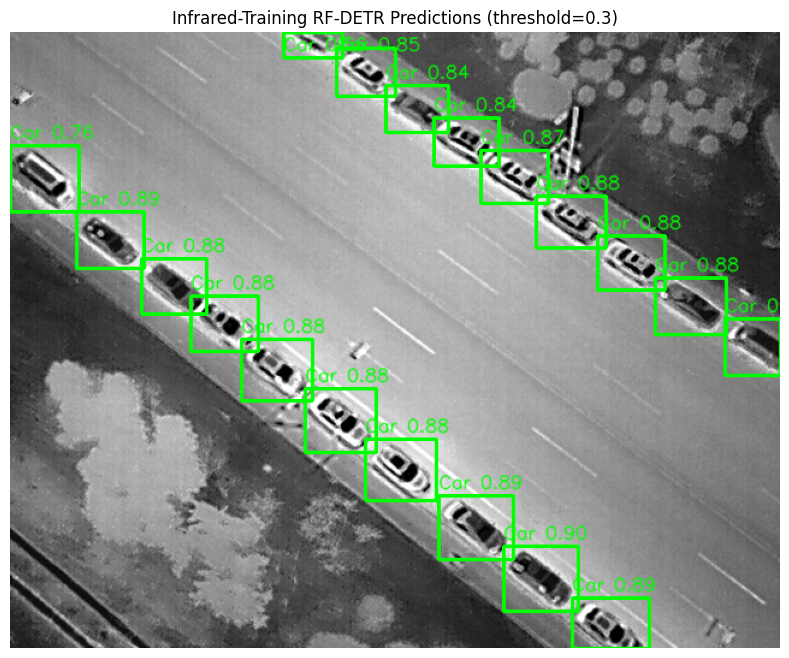

In [20]:
# ============================================================
# Cell 14: Inference Demo Cell
# Load pinned infrared model + predict on one IR image + visualize
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt
from rfdetr import RFDETRNano

# -----------------------------
# 1) Configure inputs
# -----------------------------
# Option A: set an explicit image path
IMAGE_PATH = None
# e.g. PROJECT_ROOT / "visdrone-dronevehicle-dataset-infrared/val/valimgr/00001.jpg"

# Option B: pick a random infrared image from the DroneVehicle val split
DEFAULT_IMAGE_DIR = DATASET_STRUCTURE["val"]["ir_images_dir"]

# Checkpoint: use the pinned BEST EMA checkpoint from infrared-training-isolated
CKPT_PATH = PROJECT_ROOT / "models" / "infrared-training-isolated" / "dronevehicle_rfdetr_nano_best_ema.pth"

# Fallback to latest resume if best EMA is unavailable
FALLBACK_CKPT_PATH = PROJECT_ROOT / "models" / "infrared-training-isolated" / "dronevehicle_rfdetr_nano_latest_resume.pth"

# Prediction threshold
THRESHOLD = 0.30

# Whether to crop the 100px white border before prediction/visualization
APPLY_BORDER_CROP = DRONEVEHICLE_BORDER_POLICY["remove_white_border"]

# -----------------------------
# 2) Resolve image path
# -----------------------------
def collect_image_files(folder: Path):
    valid_suffixes = {".jpg", ".jpeg", ".png"}
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_suffixes]
    )

if IMAGE_PATH is None:
    assert DEFAULT_IMAGE_DIR.exists(), f"Default image dir not found: {DEFAULT_IMAGE_DIR}"
    imgs = collect_image_files(DEFAULT_IMAGE_DIR)
    assert len(imgs) > 0, f"No images found in: {DEFAULT_IMAGE_DIR}"
    rng = random.Random(SEED)
    image_path = rng.choice(imgs)
else:
    image_path = Path(IMAGE_PATH)

assert image_path.exists(), f"Image path does not exist: {image_path}"
print("Image:", image_path)

# -----------------------------
# 3) Resolve checkpoint path
# -----------------------------
if CKPT_PATH.exists():
    resolved_ckpt = CKPT_PATH
elif FALLBACK_CKPT_PATH.exists():
    resolved_ckpt = FALLBACK_CKPT_PATH
else:
    raise FileNotFoundError(
        "No infrared-training-isolated checkpoint found.\n"
        f"Tried:\n- {CKPT_PATH}\n- {FALLBACK_CKPT_PATH}"
    )

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# 4) Optional border crop
# -----------------------------
def crop_white_border(img_bgr):
    if not APPLY_BORDER_CROP:
        return img_bgr

    left = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["left"])
    right = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["right"])
    top = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["top"])
    bottom = int(DRONEVEHICLE_BORDER_POLICY["border_pixels"]["bottom"])

    h, w = img_bgr.shape[:2]

    cropped = img_bgr[top:h-bottom, left:w-right]

    expected_w = int(DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["width"])
    expected_h = int(DRONEVEHICLE_BORDER_POLICY["expected_cropped_size"]["height"])

    assert cropped.shape[1] == expected_w, (
        f"Cropped width mismatch. Expected {expected_w}, got {cropped.shape[1]}"
    )
    assert cropped.shape[0] == expected_h, (
        f"Cropped height mismatch. Expected {expected_h}, got {cropped.shape[0]}"
    )

    return cropped

img_bgr_original = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
if img_bgr_original is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_bgr_for_inference = crop_white_border(img_bgr_original)

temp_infer_path = None
if APPLY_BORDER_CROP:
    temp_infer_path = image_path.with_name(image_path.stem + "_cropped_for_inference.jpg")
    ok = cv2.imwrite(str(temp_infer_path), img_bgr_for_inference)
    assert ok, f"Failed to write temporary cropped inference image: {temp_infer_path}"
    inference_path = temp_infer_path
else:
    inference_path = image_path

# -----------------------------
# 5) Load model
# -----------------------------
global _RFD_MODEL, _RFD_CKPT
if (
    "_RFD_MODEL" not in globals()
    or "_RFD_CKPT" not in globals()
    or _RFD_CKPT != str(resolved_ckpt)
):
    print("Loading model from checkpoint (this happens once per kernel)...")
    _RFD_MODEL = RFDETRNano(num_classes=NUM_CLASSES, pretrain_weights=str(resolved_ckpt))
    _RFD_CKPT = str(resolved_ckpt)
    _RFD_MODEL.model.model.to(device)
    _RFD_MODEL.model.model.eval()

print("Loaded checkpoint:", resolved_ckpt.name)
print("Device:", device)
print("Canonical classes:", PHASE3_CLASS_NAMES)
print("Inference image:", inference_path)

# -----------------------------
# 6) Predict
# -----------------------------
det = _RFD_MODEL.predict(str(inference_path), threshold=THRESHOLD)
boxes = det.xyxy
scores = det.confidence
class_ids = det.class_id

print(f"Detections: {len(boxes)} (threshold={THRESHOLD})")

# -----------------------------
# 7) Visualize
# -----------------------------
img_rgb = cv2.cvtColor(img_bgr_for_inference, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(boxes, scores, class_ids):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)

    label = class_id_to_name(cls)
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(15, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Infrared-Training RF-DETR Predictions (threshold={THRESHOLD})")
plt.show()

# -----------------------------
# 8) Cleanup temp file
# -----------------------------
if temp_infer_path is not None and temp_infer_path.exists():
    try:
        temp_infer_path.unlink()
    except Exception:
        pass